<a href="https://colab.research.google.com/github/mindioanni/LandLevelTools/blob/main/GINAN_PEA_PPP_timeseries_post_processor_v1_20260203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PPP post-processing (GINAN PEA POS/TRACE)
_______________________________________________________________________________
## A) Credits:

### 1. Conceptualization / Author / Developer (User):
**Ioannis Mintourakis,**

Postdoctoral Researcher (Sea Level / Geodesy)  

Hellenic National Tsunami Warning Centre (HL-NTWC)  
Institute of Geodynamics, National Observatory of Athens, Greece  
cellphone : ++30-6942556965  
e-mail : i.mintourakis@noa.gr / mindioanni@gmail.com

Greetings from: 37° 58' 30.28"N  &nbsp;&nbsp;&nbsp;&nbsp;23° 46' 47.90"E  

### 2. Author / Developer (Assistant):
**R**

The name **"R"** is inspired by me from the robot characters in the **Isaac Asimov** series.

The real identity of my Assistant is:

OpenAI. (2026, February 3). ChatGPT (GPT-5.2 Thinking) [Large language model]. Retrieved February 3, 2026, from https://chatgpt.com/

_______________________________________________________________________________
## B) Purpose:
This notebook performs **post-processing** of PPP results produced by **GINAN/PEA**, using as primary inputs:
- **POS** files (position time series)
- **TRACE** files (metadata + embedded strategy/config + diagnostics)

It produces a **single HTML report** including:
- recursive file discovery and grouping into sessions,
- POS↔TRACE association per session (with time-tolerance handling),
- extraction of embedded TRACE strategy (YAML),
- Tier-1 strategy consistency checks across sessions,
- per-session/per-variant statistics and plots (straight vs smoothed),
- a consolidated warnings summary.

_______________________________________________________________________________
## C) Quick start:
1) Run **SINGLE CELL (0+1+2)** and select the input source:  
   - **A)** Upload, or  
   - **B)** Google Drive (search-by-folder-name is recommended to avoid Unicode path issues).

2) The notebook defines the data root as `scan_root` (the folder where the input files are located).

3) Run the cells sequentially: **CELL 3 → CELL 12**.

4) Output:
   - The HTML report is generated in the runtime and (when Google Drive is used as input) it is additionally saved to:
     **`scan_root/Output/`** (created automatically).
   - A download option is also provided via the Colab environment.


In [ ]:
# ============================================================
# SINGLE CELL (0+1+2) — Environment + input acquisition + discovery/classification + init HTML report
# (Updated: option C implemented — unknown => straight only when smoothed sibling exists for same kind/base)
# ============================================================

# ---------- Imports ----------
import os, zipfile, datetime, re
from pathlib import Path
from html import escape as html_escape

import pandas as pd
import numpy as np

from google.colab import files
from google.colab import drive

# ---------- Settings / Directories ----------
WORK_DIR   = Path("/content/ppp_work")
INPUT_DIR  = WORK_DIR / "inputs"
REPORT_DIR = WORK_DIR / "reports"
INPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# timezone-aware UTC timestamp
TS_UTC = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
REPORT_HTML = REPORT_DIR / f"PPP_report_{TS_UTC}.html"

# ---------- Global structures ----------
SESSIONS = {}                 # session_id -> dict (populated later)
REFERENCE_STRATEGY = None     # set after first session strategy extraction
STRATEGY_DIFFS = []           # accumulated mismatches across sessions (tiered)

# ---------- Policy constants ----------
TRACE_POS_TIME_TOL_SEC = 5    # tolerance TRACE start_epoch vs POS First Epoch (seconds)

# Tier-1 (strategy-defining parameters; initial agreed list — adjust later if needed)
TIER1_KEYS = [
    ("receiver_options.global", "elevation_mask"),
    ("receiver_options.global", "error_model"),
    ("receiver_options.global", "code_sigma"),
    ("receiver_options.global", "phase_sigma"),
    ("receiver_options.global", "rec_reference_system"),
    ("receiver_options.global.models.troposphere", "enable"),
    ("receiver_options.global.models.troposphere", "models"),
    ("receiver_options.global.models.tides", "enable"),
    ("receiver_options.global.models.tides", "solid"),
    ("receiver_options.global.models.tides", "otl"),
    ("receiver_options.global.models.tides", "atl"),
    ("receiver_options.global.models.tides", "opole"),
    ("receiver_options.global.models.tides", "spole"),

    ("processing_options.process_modes", "preprocessor"),
    ("processing_options.process_modes", "spp"),
    ("processing_options.process_modes", "ppp"),
    ("processing_options.process_modes", "ionosphere"),
    ("processing_options.epoch_control", "epoch_interval"),
    ("processing_options.gnss_general", "use_primary_signals"),
    ("processing_options.gnss_general.sys_options", "gps"),
    ("processing_options.gnss_general.sys_options", "gal"),
    ("processing_options.gnss_general.sys_options", "bds"),
    ("processing_options.gnss_general.sys_options", "glo"),
    ("processing_options.gnss_general.sys_options", "qzs"),
    ("processing_options.ppp_filter.rts", "enable"),
    ("processing_options.ppp_filter.rts", "lag"),
    ("processing_options.ppp_filter.rts", "inverter"),
]
TIERS = {"Tier-1": TIER1_KEYS}

# ---------- HTML helpers ----------
def html_warn(msg: str) -> str:
    return f"<b style='color:#b00020'>WARNING:</b> <b style='color:#b00020'>{html_escape(msg)}</b>"

def report_init():
    html = []
    html.append("<!doctype html><html><head><meta charset='utf-8'>")
    html.append("<title>PPP Post-processing Report</title>")
    html.append("<style>"
                "body{font-family:Arial,Helvetica,sans-serif;max-width:1200px;margin:20px;}"
                "code{background:#f4f4f4;padding:2px 4px;}"
                "table{border-collapse:collapse;}"
                "td,th{border:1px solid #ccc;padding:6px 8px;vertical-align:top;}"
                "</style>")
    html.append("</head><body>")
    html.append("<h1>PPP Post-processing Report</h1>")
    html.append(f"<p><b>Generated (UTC):</b> {TS_UTC}</p>")
    html.append("<hr>")
    REPORT_HTML.write_text("\n".join(html), encoding="utf-8")

def report_append(html_fragment: str):
    with REPORT_HTML.open("a", encoding="utf-8") as f:
        f.write("\n" + html_fragment + "\n")

def report_close():
    report_append("</body></html>")

# ---------- Drive helpers ----------
DRIVE_MOUNTPOINT = Path("/content/drive")

def ensure_drive_mounted():
    if not DRIVE_MOUNTPOINT.exists() or not (DRIVE_MOUNTPOINT / "MyDrive").exists():
        drive.mount(str(DRIVE_MOUNTPOINT), force_remount=False)

DEFAULT_DRIVE_WORKDIR = str((DRIVE_MOUNTPOINT / "MyDrive" / "ppp_work").resolve())

def find_drive_folders_by_name(target_name: str, include_shared: bool = True, max_hits: int = 25):
    """
    Search Drive for folders with exact basename == target_name.
    Searches in MyDrive always; optionally in Shared drives (if present).
    Returns list[Path].
    """
    hits = []

    roots = [DRIVE_MOUNTPOINT / "MyDrive"]
    if include_shared:
        # Colab may expose shared drives under /content/drive/Shareddrives
        shared_root = DRIVE_MOUNTPOINT / "Shareddrives"
        if shared_root.exists():
            roots.append(shared_root)

    # exact name match (case-sensitive for filesystem, but we also try a normalized compare)
    tgt_norm = unicodedata.normalize("NFC", target_name)

    for r in roots:
        # avoid huge traversals: still rglob but cap hits
        for p in r.rglob("*"):
            if len(hits) >= max_hits:
                return hits
            if p.is_dir():
                name_norm = unicodedata.normalize("NFC", p.name)
                if name_norm == tgt_norm:
                    hits.append(p.resolve())
    return hits

# ---------- Unicode normalization (Greek paths etc.) ----------
import unicodedata

def nfc_path(p: str) -> str:
    return unicodedata.normalize("NFC", p)

# ---------- File classification ----------
def detect_kind(path: Path) -> str:
    ext = path.suffix.lower()
    if ext == ".pos":
        return "POS"
    if ext == ".trace":
        return "TRACE"
    return "UNKNOWN"

_SMOOTH_TOKENS = ["smooth", "smoothed", "rts", "backward", "bwd"]
_STRAIGHT_TOKENS = ["straight", "forward", "fwd"]

def detect_variant(path: Path) -> str:
    """
    Heuristic classification of file variant based on filename.
    Returns: 'smoothed' | 'straight' | 'unknown'
    NOTE: We intentionally keep many files as 'unknown' here.
          Post-pass implements policy (C): unknown=>straight only when smoothed sibling exists.
    """
    name = path.name.lower()
    if any(k in name for k in _SMOOTH_TOKENS):
        return "smoothed"
    if any(k in name for k in _STRAIGHT_TOKENS):
        return "straight"
    return "unknown"

def _base_key_for_pairing(path: Path) -> str:
    """
    Build a conservative pairing key from filename, removing known 'smoothed' tokens.
    Used ONLY to apply policy (C): unknown => straight if smoothed sibling exists.
    """
    s = path.stem.lower()

    # remove common separators + tokens in a conservative way
    # e.g. "..._smoothed", "...-smoothed", "...smoothed" -> removed
    s = re.sub(r"[_\-\.]?(smoothed|smooth|rts|backward|bwd)\b", "", s)

    # collapse repeated separators/spaces
    s = re.sub(r"[\s_\-\.]+", "_", s).strip("_")
    return s

def scan_dir(root: Path):
    pos = list(root.rglob("*.pos")) + list(root.rglob("*.POS"))
    trc = list(root.rglob("*.trace")) + list(root.rglob("*.TRACE"))
    files_all = [*pos, *trc]
    files_all = sorted({p.resolve() for p in files_all}, key=lambda p: str(p).lower())
    out = []
    for p in files_all:
        out.append({"path": str(p), "kind": detect_kind(p), "variant": detect_variant(p)})
    return out

def apply_variant_policy_C(discovered):
    """
    Policy (C):
    - keep unknown by default
    - convert unknown => straight ONLY if for same kind there exists a 'smoothed' file
      sharing the same conservative base_key (filename with smoothed tokens removed).
    """
    # map (kind, base_key) -> set(variants)
    m = {}
    # store indices for unknown candidates
    unknown_idx = []

    for i, rec in enumerate(discovered):
        p = Path(rec["path"])
        k = rec["kind"]
        v = rec["variant"]
        base = _base_key_for_pairing(p)
        key = (k, base)
        m.setdefault(key, set()).add(v)
        if v == "unknown":
            unknown_idx.append(i)

    changed = 0
    for i in unknown_idx:
        rec = discovered[i]
        p = Path(rec["path"])
        key = (rec["kind"], _base_key_for_pairing(p))
        variants_here = m.get(key, set())
        if "smoothed" in variants_here:
            discovered[i]["variant"] = "straight"
            changed += 1

    return changed

# ============================================================
# Step 1/2 — Acquire inputs (Local upload OR Drive path) + Discover files
# ============================================================

report_init()
report_append("<h2>Step 1 — Inputs</h2>")
report_append("<p>Input source selection + file ingestion (upload/extract or Drive scan).</p>")

menu = """
Choose input source:
A) Upload from local computer (files and/or ZIP)
B) Use Google Drive (search by folder name OR enter absolute path)

Enter A or B:
""".strip()

choice = input(menu).strip().upper()
if choice not in {"A", "B"}:
    raise ValueError("Invalid choice. Enter A or B.")

scan_root = None
moved = []
extracted = []
drive_mode = None

if choice == "A":
    print("Please upload POS/TRACE files (any number) and/or ZIP(s) containing them.")
    uploaded = files.upload()

    # Move uploaded into INPUT_DIR
    for fn in uploaded.keys():
        src = Path("/content") / fn
        dst = INPUT_DIR / fn
        if src.exists():
            os.replace(src, dst)
            moved.append(str(dst))

    # Extract zips into INPUT_DIR/<zipstem>/
    zips = sorted(INPUT_DIR.glob("*.zip"), key=lambda p: p.name.lower())
    for z in zips:
        extract_dir = INPUT_DIR / z.stem
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(extract_dir)
        extracted.append(str(extract_dir))

    scan_root = INPUT_DIR

else:  # choice == "B"
    ensure_drive_mounted()
    print(f"Drive mounted at: {DRIVE_MOUNTPOINT}")
    print(f"Example path: {DEFAULT_DRIVE_WORKDIR}")

    sub_menu = """
Drive input mode:
1) Search by target folder name (recommended; avoids Greek/Unicode path issues)
2) Enter absolute Drive path under /content/drive

Enter 1 or 2:
""".strip()
    drive_mode = input(sub_menu).strip()

    if drive_mode not in {"1", "2"}:
        raise ValueError("Invalid selection. Enter 1 or 2.")

    if drive_mode == "1":
        target = input("Enter target folder name to locate (e.g. GINAN post processing): ").strip()
        if not target:
            raise ValueError("No target folder name provided.")
        inc_shared = input("Search also in Shared drives? (Y/N) [default: Y]: ").strip().upper()
        include_shared = (inc_shared != "N")
        hits = find_drive_folders_by_name(target, include_shared=include_shared, max_hits=25)

        if not hits:
            raise FileNotFoundError(f"No Drive folder found with name exactly: {target}")

        if len(hits) == 1:
            scan_root = hits[0]
        else:
            print("\nMultiple candidates found:")
            for i, h in enumerate(hits):
                print(f"[{i}] {h}")
            sel = input("Select index: ").strip()
            if not sel.isdigit() or int(sel) < 0 or int(sel) >= len(hits):
                raise ValueError("Invalid index selection.")
            scan_root = hits[int(sel)]

        print(f"Selected Drive folder: {scan_root}")

    else:  # drive_mode == "2"
        drive_source = input(
            "Enter Google Drive folder path to scan (absolute path under /content/drive): "
        ).strip()
        if not drive_source:
            raise ValueError("No Drive path provided.")

        # normalize NFC to avoid composed/decomposed Greek mismatches
        drive_source_nfc = nfc_path(drive_source)
        scan_root = Path(drive_source_nfc).expanduser().resolve()
        if not scan_root.exists():
            raise FileNotFoundError(f"Drive path does not exist: {scan_root}")

# ---------- Discovery ----------
DISCOVERED = scan_dir(scan_root)

# Apply policy (C): unknown=>straight only when smoothed sibling exists (same kind/base)
n_changed = apply_variant_policy_C(DISCOVERED)

# ---------- Console output ----------
print("\nWORK_DIR:", WORK_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("REPORT_HTML:", REPORT_HTML)
print("Scan root:", scan_root)

if moved:
    print("\nUploaded/moved files:")
    for p in moved:
        print(" -", p)

if extracted:
    print("\nExtracted ZIP directories:")
    for p in extracted:
        print(" -", p)

print("\nDiscovered files:", len(DISCOVERED))
for i, rec in enumerate(DISCOVERED[:200]):
    print(f"[{i:03d}] {rec['kind']:5s} | {rec['variant']:8s} | {rec['path']}")
if len(DISCOVERED) > 200:
    print(f"... ({len(DISCOVERED)-200} more)")
if n_changed:
    print(f"\nVariant policy (C): reclassified {n_changed} 'unknown' -> 'straight' (only when smoothed sibling existed).")

# ---------- Report (Step 1 + Step 2) ----------
report_append(f"<p><b>WORK_DIR:</b> {html_escape(str(WORK_DIR))}</p>")
report_append(f"<p><b>INPUT_DIR:</b> {html_escape(str(INPUT_DIR))}</p>")
report_append(f"<p><b>REPORT_HTML:</b> {html_escape(str(REPORT_HTML))}</p>")
report_append(f"<p><b>Input source:</b> {html_escape(choice)} &nbsp; | &nbsp; <b>Scan root:</b> {html_escape(str(scan_root))}</p>")

if choice == "B" and drive_mode is not None:
    report_append(f"<p><b>Drive mode:</b> {html_escape(drive_mode)}</p>")

if moved:
    report_append("<h3>Uploaded/moved files</h3><ul>" + "".join([f"<li><code>{html_escape(p)}</code></li>" for p in moved]) + "</ul>")
if extracted:
    report_append("<h3>Extracted ZIP directories</h3><ul>" + "".join([f"<li><code>{html_escape(p)}</code></li>" for p in extracted]) + "</ul>")

report_append("<h2>Step 2 — Discovered files</h2>")
report_append("<p>Variant policy: <code>(C) unknown =&gt; straight</code> only when a <code>smoothed</code> sibling exists for the same kind/base filename.</p>")
if n_changed:
    report_append(f"<p><b>Reclassified:</b> {n_changed} file(s) from <code>unknown</code> to <code>straight</code> under policy (C).</p>")

rows = []
for rec in DISCOVERED:
    rows.append(
        "<tr>"
        f"<td>{html_escape(rec['kind'])}</td>"
        f"<td>{html_escape(rec['variant'])}</td>"
        f"<td><code>{html_escape(rec['path'])}</code></td>"
        "</tr>"
    )
table = (
    "<table>"
    "<tr><th>Kind</th><th>Variant</th><th>Path</th></tr>"
    + "".join(rows) +
    "</table>"
)
report_append(table)

# Minimal expectations (soft checks here; strict session logic later)
if not any(r["kind"] == "POS" for r in DISCOVERED):
    report_append(html_warn("No POS files discovered. Subsequent steps will fail."))
    raise ValueError("No POS files discovered under scan root.")
if not any(r["kind"] == "TRACE" for r in DISCOVERED):
    report_append(html_warn("No TRACE files discovered. Strategy checks may be limited."))
    print("WARNING: No TRACE files discovered (strategy checks may be limited).")


Choose input source:
A) Upload from local computer (files and/or ZIP)
B) Use Google Drive (search by folder name OR enter absolute path)

Enter A or B:B
Mounted at /content/drive
Drive mounted at: /content/drive
Example path: /content/drive/MyDrive/ppp_work
Drive input mode:
1) Search by target folder name (recommended; avoids Greek/Unicode path issues)
2) Enter absolute Drive path under /content/drive

Enter 1 or 2:1
Enter target folder name to locate (e.g. GINAN post processing): GINAN post processing
Search also in Shared drives? (Y/N) [default: Y]: Y
Selected Drive folder: /content/drive/MyDrive/ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/GINAN post processing

WORK_DIR: /content/ppp_work
INPUT_DIR: /content/ppp_work/inputs
REPORT_HTML: /content/ppp_work/reports/PPP_report_20260203T121840Z.html
Scan root: /content/drive/MyDrive/ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/GINAN post processing

Discovered files: 4
[000] POS   | straight | /content/drive/MyDrive/ΕΡΕΥΝΑ/Γεωδυναμικό

In [ ]:
# ============================================================
# CELL 3 — Parse session identifiers (POS-driven) & build SESSIONS
# ============================================================

import datetime
from pathlib import Path

# ---------- POS parsing helpers ----------
_MONTHS = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct":10, "nov":11, "dec":12
}

def _try_parse_datetime_tokens(s: str):
    """
    Accepts a wide range of datetime formats commonly seen in GINAN outputs.
    Returns timezone-aware UTC datetime or None.
    Supported examples:
      - 2026-Jan-19 08:01:45
      - 2026-01-19 08:01:45
      - 2026/01/19 08:01:45
      - 2026-01-19T08:01:45
    """
    s = s.strip().replace("T", " ")
    # normalize separators
    s = re.sub(r"\s+", " ", s)

    # 1) YYYY-Mon-DD HH:MM:SS
    m = re.search(r"(\d{4})-([A-Za-z]{3})-(\d{2})\s+(\d{2}):(\d{2}):(\d{2})", s)
    if m:
        y = int(m.group(1))
        mon = _MONTHS.get(m.group(2).lower())
        if mon:
            d = int(m.group(3))
            hh, mm, ss = int(m.group(4)), int(m.group(5)), int(m.group(6))
            return datetime.datetime(y, mon, d, hh, mm, ss, tzinfo=datetime.timezone.utc)

    # 2) YYYY-MM-DD HH:MM:SS or YYYY/MM/DD HH:MM:SS
    m = re.search(r"(\d{4})[-/](\d{2})[-/](\d{2})\s+(\d{2}):(\d{2}):(\d{2})", s)
    if m:
        y, mon, d = int(m.group(1)), int(m.group(2)), int(m.group(3))
        hh, mm, ss = int(m.group(4)), int(m.group(5)), int(m.group(6))
        return datetime.datetime(y, mon, d, hh, mm, ss, tzinfo=datetime.timezone.utc)

    return None

def parse_pos_first_epoch(pos_path: Path, max_head_lines: int = 300):
    """
    Reads POS header and extracts First Epoch.
    Looks for keywords: 'first epoch', 'first_epoch', 'start_epoch'.
    Returns datetime (UTC tz-aware) or None.
    """
    key_patterns = [
        r"first\s*epoch",
        r"first_epoch",
        r"start_epoch",
    ]
    key_re = re.compile("|".join(key_patterns), flags=re.IGNORECASE)

    with pos_path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(max_head_lines):
            line = f.readline()
            if not line:
                break
            if key_re.search(line):
                # grab everything after ':' if present, else entire line
                rhs = line.split(":", 1)[1] if ":" in line else line
                dt = _try_parse_datetime_tokens(rhs)
                if dt:
                    return dt
    return None

def parse_pos_last_epoch(pos_path: Path, max_tail_lines: int = 6000):
    """
    Attempts to extract last epoch from POS data lines by scanning from the end.
    Robust fallback: searches for any recognizable datetime token in the tail.
    Returns datetime (UTC tz-aware) or None.
    """
    # read tail efficiently (lines from end)
    try:
        # small files: just read all
        text = pos_path.read_text(encoding="utf-8", errors="ignore")
        lines = text.splitlines()
    except Exception:
        return None

    # scan backwards, but cap
    n = len(lines)
    start = max(0, n - max_tail_lines)
    for i in range(n - 1, start - 1, -1):
        line = lines[i].strip()
        if not line:
            continue
        dt = _try_parse_datetime_tokens(line)
        if dt:
            return dt

    return None

def session_id_from_dt(dt: datetime.datetime) -> str:
    return dt.strftime("%Y%m%dT%H%M%S")

# ---------- Build SESSIONS (POS-driven) ----------
report_append("<h2>Step 3 — Sessions from POS</h2>")
report_append("<p>Sessions are defined deterministically from POS <code>First Epoch</code>.</p>")

pos_records = [r for r in DISCOVERED if r.get("kind") == "POS"]
if not pos_records:
    report_append(html_warn("No POS files available to build sessions."))
    raise ValueError("No POS files found in DISCOVERED (cannot build SESSIONS).")

# reset SESSIONS (safe if re-running cell)
SESSIONS.clear()

unparsed = []
for rec in pos_records:
    p = Path(rec["path"])
    if not p.exists():
        unparsed.append((str(p), "missing file"))
        continue

    first_dt = parse_pos_first_epoch(p)
    if first_dt is None:
        unparsed.append((str(p), "could not parse First Epoch"))
        continue

    end_dt = parse_pos_last_epoch(p)  # optional; may be None
    sid = session_id_from_dt(first_dt)

    # variant mapping: expected 'straight'|'smoothed'; if still 'unknown', treat as straight but flag
    variant = rec.get("variant", "unknown")
    inferred_variant = False
    if variant == "unknown":
        variant = "straight"
        inferred_variant = True

    sess = SESSIONS.setdefault(sid, {
        "session_id": sid,
        "first_epoch": first_dt,
        "end_epoch": end_dt,
        "pos": {},
        "trace": {},          # filled later
        "flags": [],
        "notes": [],
    })

    # if multiple POS of same variant collide, keep first but flag
    if variant in sess["pos"]:
        sess["flags"].append(f"Duplicate POS for variant '{variant}' (kept first; ignored {p.name})")
    else:
        sess["pos"][variant] = str(p)

    # if inferred, keep note
    if inferred_variant:
        sess["notes"].append(f"Variant inferred as 'straight' for POS: {p.name}")

# report unparsed
if unparsed:
    report_append("<h3>POS files that could not be parsed</h3>")
    report_append("<ul>" + "".join([f"<li><code>{html_escape(fp)}</code> — {html_escape(reason)}</li>"
                                    for fp, reason in unparsed]) + "</ul>")
    report_append(html_warn("Some POS files could not be parsed for First Epoch; they were excluded from sessions."))

if not SESSIONS:
    report_append(html_warn("No sessions could be built from POS (all failed parsing)."))
    raise ValueError("No sessions built from POS (parsing failed).")

# determine completeness and create report table
rows = []
for sid in sorted(SESSIONS.keys()):
    sess = SESSIONS[sid]
    first_dt = sess["first_epoch"]
    end_dt = sess["end_epoch"]

    # completeness: needs straight+smoothed POS
    has_straight = "straight" in sess["pos"]
    has_smoothed = "smoothed" in sess["pos"]
    complete = has_straight and has_smoothed
    if not complete:
        sess["flags"].append("Incomplete POS set (need straight + smoothed)")

    # time span string
    first_s = first_dt.strftime("%Y-%m-%d %H:%M:%S UTC") if first_dt else "—"
    end_s = end_dt.strftime("%Y-%m-%d %H:%M:%S UTC") if end_dt else "—"

    # paths
    pos_st = sess["pos"].get("straight", "—")
    pos_sm = sess["pos"].get("smoothed", "—")

    flag_html = ""
    if sess["flags"]:
        flag_html = "<br>".join([html_warn(f) for f in sess["flags"]])

    note_html = ""
    if sess["notes"]:
        note_html = "<br>".join([f"<i>{html_escape(n)}</i>" for n in sess["notes"]])

    rows.append(
        "<tr>"
        f"<td><code>{html_escape(sid)}</code></td>"
        f"<td>{html_escape(first_s)}</td>"
        f"<td>{html_escape(end_s)}</td>"
        f"<td>{'YES' if complete else '<b style=\"color:#b00020\">NO</b>'}</td>"
        f"<td><code>{html_escape(pos_st)}</code><br><code>{html_escape(pos_sm)}</code></td>"
        f"<td>{flag_html}{('<br>' if (flag_html and note_html) else '')}{note_html}</td>"
        "</tr>"
    )

table = (
    "<table>"
    "<tr>"
    "<th>session_id</th>"
    "<th>First Epoch</th>"
    "<th>End (from last data line)</th>"
    "<th>Complete POS?</th>"
    "<th>POS paths (straight / smoothed)</th>"
    "<th>Flags / Notes</th>"
    "</tr>"
    + "".join(rows) +
    "</table>"
)
report_append(table)

# ---------- Console summary ----------
print(f"Built sessions from POS: {len(SESSIONS)}")
for sid in sorted(SESSIONS.keys()):
    sess = SESSIONS[sid]
    complete = ("straight" in sess["pos"]) and ("smoothed" in sess["pos"])
    print(f" - {sid} | POS straight: {'Y' if 'straight' in sess['pos'] else 'N'} | POS smoothed: {'Y' if 'smoothed' in sess['pos'] else 'N'} | complete: {complete}")

# Also show where report is
print("\nReport HTML:", REPORT_HTML)


Built sessions from POS: 1
 - 20260119T080145 | POS straight: Y | POS smoothed: Y | complete: True

Report HTML: /content/ppp_work/reports/PPP_report_20260203T121840Z.html


In [ ]:
# ============================================================
# CELL 4 — Attach TRACE files to sessions (TRACE start_epoch)
# ============================================================

import re
import datetime
from pathlib import Path

# ---------- Guards (if prior helpers not present) ----------
if "_try_parse_datetime_tokens" not in globals():
    _MONTHS = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
        "jul": 7, "aug": 8, "sep": 9, "oct":10, "nov":11, "dec":12
    }
    def _try_parse_datetime_tokens(s: str):
        s = s.strip().replace("T", " ")
        s = re.sub(r"\s+", " ", s)

        m = re.search(r"(\d{4})-([A-Za-z]{3})-(\d{2})\s+(\d{2}):(\d{2}):(\d{2})", s)
        if m:
            y = int(m.group(1))
            mon = _MONTHS.get(m.group(2).lower())
            if mon:
                d = int(m.group(3))
                hh, mm, ss = int(m.group(4)), int(m.group(5)), int(m.group(6))
                return datetime.datetime(y, mon, d, hh, mm, ss, tzinfo=datetime.timezone.utc)

        m = re.search(r"(\d{4})[-/](\d{2})[-/](\d{2})\s+(\d{2}):(\d{2}):(\d{2})", s)
        if m:
            y, mon, d = int(m.group(1)), int(m.group(2)), int(m.group(3))
            hh, mm, ss = int(m.group(4)), int(m.group(5)), int(m.group(6))
            return datetime.datetime(y, mon, d, hh, mm, ss, tzinfo=datetime.timezone.utc)

        return None

def _session_id_from_dt(dt: datetime.datetime) -> str:
    return dt.strftime("%Y%m%dT%H%M%S")

def parse_trace_header(trace_path: Path, max_head_lines: int = 600):
    """
    Extracts from TRACE header:
      - start_epoch
      - end_epoch
      - pea_version
      - trace_level
    Returns dict with dt objects (UTC tz-aware) or None for missing.
    """
    out = {"start_epoch": None, "end_epoch": None, "pea_version": None, "trace_level": None}

    re_start = re.compile(r"^\s*start_epoch\s*:\s*(.+?)\s*$", re.IGNORECASE)
    re_end   = re.compile(r"^\s*end_epoch\s*:\s*(.+?)\s*$", re.IGNORECASE)
    re_ver   = re.compile(r"^\s*pea_version\s*:\s*(.+?)\s*$", re.IGNORECASE)
    re_lvl   = re.compile(r"^\s*trace_level\s*:\s*(.+?)\s*$", re.IGNORECASE)

    with trace_path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(max_head_lines):
            line = f.readline()
            if not line:
                break

            m = re_start.match(line)
            if m and out["start_epoch"] is None:
                out["start_epoch"] = _try_parse_datetime_tokens(m.group(1))

            m = re_end.match(line)
            if m and out["end_epoch"] is None:
                out["end_epoch"] = _try_parse_datetime_tokens(m.group(1))

            m = re_ver.match(line)
            if m and out["pea_version"] is None:
                out["pea_version"] = m.group(1).strip()

            m = re_lvl.match(line)
            if m and out["trace_level"] is None:
                # keep as string; could be "2" or "2.0" etc.
                out["trace_level"] = m.group(1).strip()

            # early exit if all captured
            if all(out[k] is not None for k in ["start_epoch", "end_epoch", "pea_version", "trace_level"]):
                break

    return out

def _nearest_session_id_by_dt(dt: datetime.datetime):
    """
    Returns (best_session_id, best_abs_dt_seconds) based on SESSIONS[*]['first_epoch'].
    """
    best_sid = None
    best_abs = None
    for sid, sess in SESSIONS.items():
        sdt = sess.get("first_epoch")
        if sdt is None:
            continue
        dsec = abs((dt - sdt).total_seconds())
        if (best_abs is None) or (dsec < best_abs):
            best_abs = dsec
            best_sid = sid
    return best_sid, best_abs

# ---------- Attach TRACE files ----------
report_append("<h2>Step 4 — TRACE attachment</h2>")
report_append("<p>TRACE files are attached to sessions using TRACE <code>start_epoch</code> compared to POS-derived <code>session_id</code> (First Epoch).</p>")

# Ensure session dict has expected containers
for sid, sess in SESSIONS.items():
    sess.setdefault("trace", {})
    sess.setdefault("trace_meta", {})
    sess.setdefault("flags", [])
    sess.setdefault("notes", [])

trace_records = [r for r in DISCOVERED if r.get("kind") == "TRACE"]
if not trace_records:
    report_append(html_warn("No TRACE files discovered. Strategy checks will be limited."))
    print("WARNING: No TRACE files discovered (strategy checks will be limited).")
else:
    rows = []
    unattached = []

    # For post-pass rule: unknown=>straight only when smoothed exists for same kind/session
    # We'll temporarily store unknown as 'unknown' variant under session["trace"] and resolve later.
    for rec in trace_records:
        p = Path(rec["path"])
        variant = rec.get("variant", "unknown")  # 'smoothed'|'straight'|'unknown'

        if not p.exists():
            unattached.append((str(p), "missing file"))
            rows.append(
                "<tr>"
                f"<td>TRACE</td><td>{html_escape(variant)}</td>"
                f"<td><code>{html_escape(str(p))}</code></td>"
                f"<td colspan='5'>{html_warn('File missing')}</td>"
                "</tr>"
            )
            continue

        meta = parse_trace_header(p)
        st = meta["start_epoch"]
        en = meta["end_epoch"]

        if st is None:
            unattached.append((str(p), "missing/unparsed start_epoch"))
            rows.append(
                "<tr>"
                f"<td>TRACE</td><td>{html_escape(variant)}</td>"
                f"<td><code>{html_escape(str(p))}</code></td>"
                f"<td colspan='5'>{html_warn('Could not parse start_epoch from TRACE header')}</td>"
                "</tr>"
            )
            continue

        trace_sid = _session_id_from_dt(st)

        # Exact match first
        attach_sid = None
        attach_mode = ""
        dt_sec = 0.0

        if trace_sid in SESSIONS:
            attach_sid = trace_sid
            attach_mode = "exact"
            dt_sec = 0.0
        else:
            # Nearest by |Δt|
            nearest_sid, best_abs = _nearest_session_id_by_dt(st)
            if nearest_sid is None:
                attach_sid = None
                attach_mode = "unmatched"
                dt_sec = None
            else:
                dt_sec = best_abs
                if best_abs <= TRACE_POS_TIME_TOL_SEC:
                    attach_sid = nearest_sid
                    attach_mode = "tolerance"
                else:
                    attach_sid = None
                    attach_mode = "unmatched"

        # Attach or not
        warn_html = ""
        if attach_mode == "tolerance":
            warn_html = html_warn(
                f"TRACE start_epoch does not exactly match any POS session_id. "
                f"Attached by tolerance to session {attach_sid} (|Δt|={dt_sec:.3f}s ≤ {TRACE_POS_TIME_TOL_SEC}s)."
            )
            # also keep as session flag for later visibility
            SESSIONS[attach_sid]["flags"].append(
                f"TRACE tolerance-attach: {p.name} (|Δt|={dt_sec:.3f}s)"
            )

        if attach_mode == "unmatched":
            msg = "TRACE start_epoch did not match any session within tolerance; left unattached."
            warn_html = html_warn(msg)
            unattached.append((str(p), msg))

        # Record in session structure
        if attach_sid is not None:
            sess = SESSIONS[attach_sid]
            sess.setdefault("trace", {})
            sess.setdefault("trace_meta", {})

            # Collision handling
            if variant in sess["trace"]:
                sess["flags"].append(f"Duplicate TRACE for variant '{variant}' (kept first; ignored {p.name})")
            else:
                sess["trace"][variant] = str(p)
                sess["trace_meta"][variant] = {
                    "start_epoch": st,
                    "end_epoch": en,
                    "pea_version": meta["pea_version"],
                    "trace_level": meta["trace_level"],
                }

        # Report row
        st_s = st.strftime("%Y-%m-%d %H:%M:%S UTC") if st else "—"
        en_s = en.strftime("%Y-%m-%d %H:%M:%S UTC") if en else "—"
        pea = meta["pea_version"] if meta["pea_version"] else "—"
        lvl = meta["trace_level"] if meta["trace_level"] else "—"
        dt_s = "—" if dt_sec is None else f"{dt_sec:.3f}"

        status = attach_mode
        if attach_mode == "exact":
            status_html = "<b>exact</b>"
        elif attach_mode == "tolerance":
            status_html = "<b style='color:#b00020'>tolerance</b>"
        else:
            status_html = "<b style='color:#b00020'>unmatched</b>"

        rows.append(
            "<tr>"
            f"<td>TRACE</td>"
            f"<td>{html_escape(variant)}</td>"
            f"<td><code>{html_escape(str(p))}</code></td>"
            f"<td>{html_escape(st_s)}</td>"
            f"<td>{html_escape(en_s)}</td>"
            f"<td>{html_escape(pea)}</td>"
            f"<td>{html_escape(lvl)}</td>"
            f"<td>{html_escape(attach_sid) if attach_sid else '—'}</td>"
            f"<td>{dt_s}</td>"
            f"<td>{status_html}{('<br>'+warn_html) if warn_html else ''}</td>"
            "</tr>"
        )

    # ---------- Post-pass: apply rule (C) unknown=>straight only when smoothed exists for same kind/session ----------
    # For TRACE: if session has 'smoothed' and also has 'unknown' but no 'straight' => relabel unknown->straight.
    for sid, sess in SESSIONS.items():
        tr = sess.get("trace", {})
        if ("smoothed" in tr) and ("unknown" in tr) and ("straight" not in tr):
            tr["straight"] = tr.pop("unknown")
            # move meta too
            tm = sess.get("trace_meta", {})
            if "unknown" in tm:
                tm["straight"] = tm.pop("unknown")
            sess["notes"].append("TRACE variant inferred: 'unknown' treated as 'straight' because 'smoothed' exists for same session.")

    # Also flag remaining unknown variants (not inferred)
    for sid, sess in SESSIONS.items():
        if "unknown" in sess.get("trace", {}):
            sess["flags"].append("TRACE variant remains 'unknown' (no smoothed counterpart to infer straight).")

    # ---------- Write report table ----------
    table = (
        "<table>"
        "<tr>"
        "<th>Kind</th><th>Variant</th><th>Path</th>"
        "<th>TRACE start_epoch</th><th>TRACE end_epoch</th><th>pea_version</th><th>trace_level</th>"
        "<th>Attached session_id</th><th>|Δt| (s)</th><th>Status / Warnings</th>"
        "</tr>"
        + "".join(rows) +
        "</table>"
    )
    report_append(table)

    if unattached:
        report_append("<h3>Unattached TRACE files</h3>")
        report_append("<ul>" + "".join([
            f"<li><code>{html_escape(p)}</code> — {html_escape(reason)}</li>"
            for p, reason in unattached
        ]) + "</ul>")

    # ---------- Console summary ----------
    attached_count = 0
    for sid, sess in SESSIONS.items():
        attached_count += len(sess.get("trace", {}))
    print(f"TRACE files processed: {len(trace_records)}")
    print(f"TRACE attachments recorded in sessions (counting variants): {attached_count}")

    # Quick per-session view
    for sid in sorted(SESSIONS.keys()):
        tr = SESSIONS[sid].get("trace", {})
        print(f" - {sid} | TRACE straight: {'Y' if 'straight' in tr else 'N'} | TRACE smoothed: {'Y' if 'smoothed' in tr else 'N'} | TRACE unknown: {'Y' if 'unknown' in tr else 'N'}")


TRACE files processed: 2
TRACE attachments recorded in sessions (counting variants): 2
 - 20260119T080145 | TRACE straight: Y | TRACE smoothed: Y | TRACE unknown: N


In [ ]:
# ============================================================
# CELL 5 — Sessions discovered summary table (paths per session)
# ============================================================

from pathlib import Path
from html import escape as html_escape

def _code_path(p):
    return f"<code>{html_escape(str(p))}</code>" if p else "—"

def _count_list(x):
    if x is None:
        return 0
    if isinstance(x, (list, tuple)):
        return len(x)
    return 1

report_append("<h2>Step 5 — Sessions discovered</h2>")
report_append("<p>Summary table of sessions (POS-driven) with attached TRACE files and flags.</p>")

rows = []
for sid in sorted(SESSIONS.keys()):
    sess = SESSIONS[sid]

    pos = sess.get("pos", {})
    trc = sess.get("trace", {})

    pos_st = pos.get("straight")
    pos_sm = pos.get("smoothed")
    tr_st  = trc.get("straight")
    tr_sm  = trc.get("smoothed")

    flags = sess.get("flags", []) or []
    notes = sess.get("notes", []) or []

    # Missing items (explicit)
    missing = []
    if not pos_st: missing.append("POS straight")
    if not pos_sm: missing.append("POS smoothed")
    if not tr_st:  missing.append("TRACE straight")
    if not tr_sm:  missing.append("TRACE smoothed")

    warn_count = len(flags)
    note_count = len(notes)

    # Compact flags display
    flags_html = "—"
    if flags:
        flags_html = "<ul style='margin:0;padding-left:18px;'>" + "".join(
            f"<li>{html_escape(f)}</li>" for f in flags[:12]
        ) + "</ul>"
        if len(flags) > 12:
            flags_html += f"<div>… ({len(flags)-12} more)</div>"

    notes_html = "—"
    if notes:
        notes_html = "<ul style='margin:0;padding-left:18px;'>" + "".join(
            f"<li>{html_escape(n)}</li>" for n in notes[:10]
        ) + "</ul>"
        if len(notes) > 10:
            notes_html += f"<div>… ({len(notes)-10} more)</div>"

    # Timespan (if present)
    first_epoch = sess.get("first_epoch")
    end_epoch = sess.get("end_epoch")
    span_html = "—"
    if first_epoch is not None:
        fe = first_epoch.strftime("%Y-%m-%d %H:%M:%S UTC") if hasattr(first_epoch, "strftime") else str(first_epoch)
        ee = end_epoch.strftime("%Y-%m-%d %H:%M:%S UTC") if (end_epoch is not None and hasattr(end_epoch, "strftime")) else ("—" if end_epoch is None else str(end_epoch))
        span_html = f"{html_escape(fe)} → {html_escape(ee)}"

    # Highlight incomplete sessions
    incomplete = (len(missing) > 0)
    sid_html = f"<b>{html_escape(sid)}</b>" if not incomplete else f"<b style='color:#b00020'>{html_escape(sid)}</b>"

    missing_html = "—"
    if missing:
        missing_html = "<b style='color:#b00020'>" + html_escape(", ".join(missing)) + "</b>"

    rows.append(
        "<tr>"
        f"<td>{sid_html}</td>"
        f"<td>{span_html}</td>"
        f"<td>{_code_path(pos_st)}</td>"
        f"<td>{_code_path(pos_sm)}</td>"
        f"<td>{_code_path(tr_st)}</td>"
        f"<td>{_code_path(tr_sm)}</td>"
        f"<td>{missing_html}</td>"
        f"<td>{warn_count}</td>"
        f"<td>{flags_html}</td>"
        f"<td>{notes_html}</td>"
        "</tr>"
    )

table = (
    "<table>"
    "<tr>"
    "<th>session_id</th>"
    "<th>timespan (POS)</th>"
    "<th>POS straight</th>"
    "<th>POS smoothed</th>"
    "<th>TRACE straight</th>"
    "<th>TRACE smoothed</th>"
    "<th>missing items</th>"
    "<th>warnings</th>"
    "<th>flags (details)</th>"
    "<th>notes</th>"
    "</tr>"
    + "".join(rows) +
    "</table>"
)
report_append(table)

# Console summary
n_sessions = len(SESSIONS)
n_complete = 0
for sid, sess in SESSIONS.items():
    pos = sess.get("pos", {})
    trc = sess.get("trace", {})
    if pos.get("straight") and pos.get("smoothed") and trc.get("straight") and trc.get("smoothed"):
        n_complete += 1
print(f"Sessions discovered: {n_sessions} | Complete (POS+TRACE both variants): {n_complete} | Incomplete: {n_sessions - n_complete}")


Sessions discovered: 1 | Complete (POS+TRACE both variants): 1 | Incomplete: 0


In [ ]:
# ============================================================
# CELL 6 — Extract embedded YAML strategy from TRACE (per session, per variant)
# ============================================================

import re, json, hashlib
from pathlib import Path
from html import escape as html_escape

# ---------- YAML parser: prefer PyYAML, fallback to conservative parser ----------
try:
    import yaml  # PyYAML (usually available in Colab)
    _HAVE_YAML = True
except Exception:
    yaml = None
    _HAVE_YAML = False

def _extract_yaml_block_from_trace(text: str) -> str:
    """
    Extracts the embedded YAML configuration block from a GINAN TRACE file.

    Heuristic:
      start: line containing '+FILE/RAW_CONFIG'
      end:   line containing '-FILE/RAW_CONFIG'
             OR first epoch/residual section markers (e.g., '------===============', '+RESIDUALS/')
    Returns YAML text (may be empty string if not found).
    """
    lines = text.splitlines()

    # find start
    start_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("+FILE/RAW_CONFIG"):
            start_idx = i + 1
            break
    if start_idx is None:
        return ""

    # find end
    end_idx = len(lines)
    for j in range(start_idx, len(lines)):
        s = lines[j].strip()
        if s.startswith("-FILE/RAW_CONFIG"):
            end_idx = j
            break
        if s.startswith("------=============== Epoch") or s.startswith("+RESIDUALS/") or s.startswith("+STATES/"):
            end_idx = j
            break

    block = "\n".join(lines[start_idx:end_idx]).strip("\n")
    return block.strip()

def _parse_yaml_to_dict(yaml_text: str):
    """
    Parse YAML to dict. If PyYAML unavailable, fallback to a conservative parser
    that supports a minimal subset (mappings, nested indentation, simple lists).
    """
    if not yaml_text.strip():
        return None

    if _HAVE_YAML:
        try:
            return yaml.safe_load(yaml_text)
        except Exception:
            # fallthrough to conservative
            pass

    # --- Conservative parser (limited YAML subset) ---
    # Supports:
    #   key: value
    #   key:
    #     nested: value
    #   key: [a, b, c]
    #   key:
    #     - item
    #     - item2
    #
    # NOTE: This is intentionally minimal; if it fails, we return None.
    try:
        def parse_scalar(v: str):
            v = v.strip()
            if v in ("true", "True"): return True
            if v in ("false", "False"): return False
            if v in ("null", "Null", "none", "None", "~"): return None
            # numbers
            try:
                if re.match(r"^[+-]?\d+$", v): return int(v)
                if re.match(r"^[+-]?\d+\.\d*([eE][+-]?\d+)?$", v) or re.match(r"^[+-]?\d+([eE][+-]?\d+)$", v):
                    return float(v)
            except Exception:
                pass
            # bracket list
            if v.startswith("[") and v.endswith("]"):
                inner = v[1:-1].strip()
                if not inner:
                    return []
                parts = [p.strip() for p in inner.split(",")]
                return [parse_scalar(p) for p in parts]
            # quoted strings
            if (v.startswith("'") and v.endswith("'")) or (v.startswith('"') and v.endswith('"')):
                return v[1:-1]
            return v

        root = {}
        stack = [(0, root)]  # (indent, current_container)
        last_key_stack = []  # for list under a key

        for raw in yaml_text.splitlines():
            if not raw.strip():
                continue
            # strip inline comments (naive, but ok for our use)
            line = raw.split("#", 1)[0].rstrip()
            if not line.strip():
                continue

            indent = len(line) - len(line.lstrip(" "))
            line = line.lstrip(" ")

            # unwind stack to current indent
            while stack and indent < stack[-1][0]:
                stack.pop()
            if not stack:
                stack = [(0, root)]

            cur = stack[-1][1]

            # list item
            if line.startswith("- "):
                item = parse_scalar(line[2:].strip())
                if isinstance(cur, list):
                    cur.append(item)
                else:
                    # if current is a dict, attach to last key if possible
                    if isinstance(cur, dict) and last_key_stack:
                        lk = last_key_stack[-1]
                        if lk not in cur or not isinstance(cur[lk], list):
                            cur[lk] = []
                        cur[lk].append(item)
                    else:
                        # cannot place list item -> fail
                        raise ValueError("Unsupported list placement")
                continue

            # key : value
            if ":" in line:
                k, v = line.split(":", 1)
                k = k.strip()
                v = v.strip()

                if v == "":
                    # start nested mapping/list
                    if isinstance(cur, dict):
                        cur[k] = {}
                        last_key_stack.append(k)
                        stack.append((indent + 2, cur[k]))
                    else:
                        raise ValueError("Nested under non-dict")
                else:
                    if isinstance(cur, dict):
                        cur[k] = parse_scalar(v)
                        if last_key_stack:
                            last_key_stack[-1] = k
                    else:
                        raise ValueError("Key/value under non-dict")
            else:
                # unsupported line
                raise ValueError("Unsupported YAML line")

        return root

    except Exception:
        return None

def _get_by_path(d: dict, path: str):
    """
    Traverse dict by dot-path. Returns None if missing.
    """
    if d is None:
        return None
    cur = d
    for part in path.split("."):
        if not isinstance(cur, dict) or part not in cur:
            return None
        cur = cur[part]
    return cur

def _extract_tier_keys(strategy_raw: dict, tier_name: str = "Tier-1") -> dict:
    """
    Extract only the strategy-defining parameters from strategy_raw, according to TIERS[tier_name].
    Returns a flat dict with keys like '<path>.<key>' -> value (may be None if missing).
    """
    out = {}
    tier_keys = TIERS.get(tier_name, [])
    for (path, key) in tier_keys:
        container = _get_by_path(strategy_raw, path)
        fullk = f"{path}.{key}"
        if isinstance(container, dict) and key in container:
            out[fullk] = container[key]
        else:
            out[fullk] = None
    return out

def _canonical_json(obj) -> str:
    return json.dumps(obj, sort_keys=True, ensure_ascii=False, default=str, separators=(",", ":"))

def _sha256_hex(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8", errors="replace")).hexdigest()

# ---------- Extraction loop ----------
report_append("<h2>Step 6 — Extracted strategy (per session)</h2>")
report_append("<p>Extract embedded YAML config from TRACE files, parse, and keep Tier-1 strategy-defining parameters for later consistency checks.</p>")

if not any(SESSIONS[s].get("trace", {}).get(v) for s in SESSIONS for v in ("straight", "smoothed")):
    report_append(html_warn("No TRACE files attached to any session. Strategy extraction will be empty."))
    print("WARNING: No TRACE files attached to any session. Strategy extraction skipped.")

rows = []
for sid in sorted(SESSIONS.keys()):
    sess = SESSIONS[sid]
    sess.setdefault("strategy", {})

    for variant in ("straight", "smoothed"):
        tpath = sess.get("trace", {}).get(variant)
        if not tpath:
            continue

        p = Path(tpath)
        txt = p.read_text(encoding="utf-8", errors="replace")
        yblock = _extract_yaml_block_from_trace(txt)

        strategy_raw = _parse_yaml_to_dict(yblock)
        if strategy_raw is None:
            msg = f"Strategy YAML parse failed for session {sid} ({variant})"
            sess.setdefault("flags", []).append(msg)
            report_append(html_warn(msg))
            continue

        tier1 = _extract_tier_keys(strategy_raw, "Tier-1")
        canon = _canonical_json(tier1)
        h = _sha256_hex(canon)[:16]

        sess["strategy"][variant] = {
            "raw": strategy_raw,      # full parsed config (may be large)
            "tier1": tier1,           # flat extracted Tier-1 map
            "tier1_canon": canon,     # canonical string for diff
            "tier1_hash16": h,        # short hash for report
        }

        # Small, readable Tier-1 table for report (collapsible)
        kv_rows = []
        for k in sorted(tier1.keys()):
            v = tier1[k]
            v_str = html_escape(_canonical_json(v) if isinstance(v, (dict, list)) else str(v))
            kv_rows.append(f"<tr><td><code>{html_escape(k)}</code></td><td><code>{v_str}</code></td></tr>")
        kv_table = (
            "<table>"
            "<tr><th>Tier-1 key</th><th>value</th></tr>"
            + "".join(kv_rows) +
            "</table>"
        )

        rows.append(
            "<tr>"
            f"<td><b>{html_escape(sid)}</b></td>"
            f"<td>{html_escape(variant)}</td>"
            f"<td><code>{html_escape(str(p))}</code></td>"
            f"<td><code>{html_escape(h)}</code></td>"
            f"<td><details><summary>show Tier-1</summary>{kv_table}</details></td>"
            "</tr>"
        )

# ---------- Report table ----------
if rows:
    table = (
        "<table>"
        "<tr><th>session_id</th><th>variant</th><th>TRACE path</th><th>Tier-1 hash</th><th>Tier-1 details</th></tr>"
        + "".join(rows) +
        "</table>"
    )
    report_append(table)
else:
    report_append(html_warn("No strategies extracted (no TRACE attached or parsing failed)."))

print("Strategy extraction completed.")


Strategy extraction completed.


In [ ]:
# ============================================================
# CELL 7 — Strategy consistency check (Tier-1 HARD)  [UPDATED]
#   - Console prints: reference session/variant/hash
#   - HTML report:
#       * shows FULL Tier-1 strategy of reference (pretty JSON)
#       * BOLD BLUE PASS or BOLD RED WARNING + detailed diff tables
#       * per-session status table
# ============================================================

import json
from html import escape as html_escape

def _canon_val(v):
    return json.dumps(v, sort_keys=True, ensure_ascii=False, default=str, separators=(",", ":"))

def _deep_equal(a, b) -> bool:
    return _canon_val(a) == _canon_val(b)

def _pretty_json(v) -> str:
    return json.dumps(v, sort_keys=True, ensure_ascii=False, indent=2, default=str)

def html_pass(msg: str) -> str:
    # Bold blue PASS
    return f"<b style='color:#0b5394'>PASS:</b> <b style='color:#0b5394'>{html_escape(msg)}</b>"

def _pick_reference_strategy():
    """
    Pick reference from first available session:
      prefer (straight) then (smoothed).
    Returns: (ref_session_id, ref_variant, ref_tier1_dict, ref_hash16)
    """
    for sid in sorted(SESSIONS.keys()):
        strat = SESSIONS[sid].get("strategy", {})
        if "straight" in strat and strat["straight"].get("tier1") is not None:
            return sid, "straight", strat["straight"]["tier1"], strat["straight"].get("tier1_hash16", "")
        if "smoothed" in strat and strat["smoothed"].get("tier1") is not None:
            return sid, "smoothed", strat["smoothed"]["tier1"], strat["smoothed"].get("tier1_hash16", "")
    return None, None, None, None

# ---------- Begin report section ----------
report_append("<h2>Step 7 — Strategy consistency (Tier-1)</h2>")
report_append("<p>Hard comparability check of Tier-1 strategy-defining parameters across sessions/variants.</p>")

# ---------- Choose reference ----------
ref_sid, ref_var, ref_tier1, ref_hash = _pick_reference_strategy()
REFERENCE_STRATEGY = None  # reset explicitly here; will set below

if ref_tier1 is None:
    msg = "No extracted Tier-1 strategy found in any session. Consistency check cannot run."
    report_append(html_warn(msg))
    print("WARNING:", msg)
    print("Tier-1 strategy consistency check completed.")
else:
    REFERENCE_STRATEGY = {
        "session_id": ref_sid,
        "variant": ref_var,
        "tier": "Tier-1",
        "tier1": ref_tier1,
        "hash16": ref_hash,
    }

    # ---------- Console prints (requested) ----------
    print(f"Tier-1 reference strategy: session={ref_sid} | variant={ref_var} | hash16={ref_hash}")

    # ---------- Report: reference metadata ----------
    report_append(
        "<p><b>Reference strategy:</b> "
        f"session <code>{html_escape(ref_sid)}</code>, variant <code>{html_escape(ref_var)}</code>, "
        f"Tier-1 hash <code>{html_escape(ref_hash)}</code></p>"
    )

    # ---------- Report: FULL Tier-1 strategy of reference (requested) ----------
    ref_pretty = html_escape(_pretty_json(ref_tier1))
    report_append(
        "<details open>"
        "<summary><b>Reference Tier-1 strategy (full)</b></summary>"
        f"<pre style='background:#f6f8fa;border:1px solid #ddd;padding:10px;overflow:auto;white-space:pre-wrap;'>"
        f"{ref_pretty}"
        "</pre>"
        "</details>"
    )

    # ---------- Compare all sessions/variants ----------
    STRATEGY_DIFFS.clear()
    overall_fail = False

    for sid in sorted(SESSIONS.keys()):
        sess = SESSIONS[sid]
        sess.setdefault("strategy_check", {})
        sess.setdefault("flags", [])

        for variant in ("straight", "smoothed"):
            srec = sess.get("strategy", {}).get(variant)
            if not srec or srec.get("tier1") is None:
                continue

            tier1 = srec["tier1"]
            this_hash = srec.get("tier1_hash16", "")

            # Fast path: hash match => PASS
            if this_hash and ref_hash and this_hash == ref_hash:
                sess["strategy_check"][variant] = {"status": "PASS", "hash16": this_hash, "diffs": []}
                continue

            diffs = []

            # Compare Tier-1 keys (from reference dict)
            for k in sorted(ref_tier1.keys()):
                ref_v = ref_tier1.get(k, None)
                cur_v = tier1.get(k, None)
                if not _deep_equal(ref_v, cur_v):
                    diffs.append(
                        {
                            "session_id": sid,
                            "variant": variant,
                            "key": k,
                            "ref": ref_v,
                            "cur": cur_v,
                        }
                    )

            if diffs:
                overall_fail = True
                sess["strategy_check"][variant] = {"status": "FAIL", "hash16": this_hash, "diffs": diffs}

                # accumulate global diffs
                STRATEGY_DIFFS.extend(diffs)

                # session-level flag
                sess["flags"].append(f"Tier-1 strategy mismatch ({variant}) vs reference {ref_sid}/{ref_var}")
            else:
                sess["strategy_check"][variant] = {"status": "PASS", "hash16": this_hash, "diffs": []}

    # ---------- Report summary PASS/FAIL (requested styling) ----------
    n_sessions_with_tier1 = 0
    for sid in SESSIONS:
        for variant in ("straight", "smoothed"):
            chk = SESSIONS[sid].get("strategy_check", {}).get(variant)
            if chk:
                n_sessions_with_tier1 += 1

    # Special case: only one session/variant effectively checked
    # (We still report PASS/FAIL based on diffs; typically PASS)
    if overall_fail:
        report_append(
            html_warn(
                "Strategy consistency: FAIL (Tier-1 mismatches detected). "
                "Cross-session comparisons are still allowed, but interpret results considering these differences."
            )
        )
    else:
        report_append(html_pass("Strategy consistency: PASS (Tier-1)."))

    # ---------- Detailed diff table (only if fail) ----------
    if STRATEGY_DIFFS:
        report_append("<h3>Tier-1 mismatches (reference vs session)</h3>")

        # group by (session, variant)
        grouped = {}
        for d in STRATEGY_DIFFS:
            grouped.setdefault((d["session_id"], d["variant"]), []).append(d)

        blocks = []
        for (sid, variant) in sorted(grouped.keys()):
            diffs = grouped[(sid, variant)]
            rows = []
            for d in diffs:
                k = d["key"]
                rv = html_escape(_pretty_json(d["ref"])) if isinstance(d["ref"], (dict, list)) else html_escape(_canon_val(d["ref"]))
                cv = html_escape(_pretty_json(d["cur"])) if isinstance(d["cur"], (dict, list)) else html_escape(_canon_val(d["cur"]))
                rows.append(
                    "<tr>"
                    f"<td><code>{html_escape(k)}</code></td>"
                    f"<td><pre style='margin:0;background:#fff;border:0;white-space:pre-wrap;'>{rv}</pre></td>"
                    f"<td><pre style='margin:0;background:#fff;border:0;white-space:pre-wrap;'>{cv}</pre></td>"
                    "</tr>"
                )

            tbl = (
                "<table>"
                "<tr><th>Tier-1 key</th><th>Reference</th><th>Session value</th></tr>"
                + "".join(rows) +
                "</table>"
            )

            blocks.append(
                "<details open>"
                f"<summary><b>Session</b> <code>{html_escape(sid)}</code> "
                f"<b>variant</b> <code>{html_escape(variant)}</code> — "
                f"{len(diffs)} mismatch(es)</summary>"
                f"{tbl}"
                "</details>"
            )

        report_append("".join(blocks))

    # ---------- Per-session status table ----------
    report_append("<h3>Per-session / variant status</h3>")
    status_rows = []
    for sid in sorted(SESSIONS.keys()):
        sess = SESSIONS[sid]
        for variant in ("straight", "smoothed"):
            chk = sess.get("strategy_check", {}).get(variant)
            if not chk:
                continue
            status = chk["status"]
            h16 = chk.get("hash16", "")
            n = len(chk.get("diffs", []))

            # style status cell
            if status == "PASS":
                status_html = "<b style='color:#0b5394'>PASS</b>"
            else:
                status_html = "<b style='color:#b00020'>FAIL</b>"

            status_rows.append(
                "<tr>"
                f"<td><code>{html_escape(sid)}</code></td>"
                f"<td><code>{html_escape(variant)}</code></td>"
                f"<td>{status_html}</td>"
                f"<td><code>{html_escape(h16)}</code></td>"
                f"<td>{n}</td>"
                "</tr>"
            )

    if status_rows:
        report_append(
            "<table>"
            "<tr><th>session_id</th><th>variant</th><th>status</th><th>Tier-1 hash</th><th>#diffs</th></tr>"
            + "".join(status_rows) +
            "</table>"
        )
    else:
        report_append(html_warn("No session/variant had an extracted Tier-1 strategy to check."))

    print("Tier-1 strategy consistency check completed.")


Tier-1 reference strategy: session=20260119T080145 | variant=straight | hash16=90ddae293a78f444
Tier-1 strategy consistency check completed.


In [ ]:
# ============================================================
# CELL 8 — POS parsing per session (both POS) + stats tables
#   Updated to support PBO/Ginan POS Format Version 2.0.0
#   (ISO epoch token: YYYY-MM-DDTHH:MM:SS.SSS with leading spaces)
#   Adds console outputs (summary + stats tables) per session/variant.
# ============================================================

import math
import numpy as np
import pandas as pd
import datetime
import re
from pathlib import Path
from html import escape as html_escape
from IPython.display import display

# ----------------------------
# POS parsing helpers
# ----------------------------

_MONTH_MAP = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct":10, "nov":11, "dec":12
}

# PBO (PBO Station Position Time Series / Format Version 2.0.0) canonical columns (after epoch token)
_PBO_REST_COLS = [
    "dec_year",
    "X","Y","Z",
    "Sx","Sy","Sz",
    "Rxy","Rxz","Ryz",
    "Nlat","Elong","Height",
    "dN","dE","dU",
    "Sn","Se","Su",
    "Rne","Rnu","Reu",
    "Soln",
]

def _is_pbo_pos(header_lines):
    # Conservative detection
    for ln in header_lines[:10]:
        s = ln.strip()
        if "PBO Station Position Time Series" in s:
            return True
    # Format Version: 2.0.0 appears in your snippet
    for ln in header_lines[:20]:
        if ln.strip().lower().startswith("format version:"):
            return True
    # Also accept presence of the PBO-style header marker line starting with "*YYYY-"
    for ln in header_lines:
        if ln.lstrip().startswith("*YYYY-"):
            return True
    return False

def _parse_iso_epoch_token(tok: str):
    """
    Parse ISO epoch token such as:
      2026-01-19T08:01:45.000
      2026-01-19T08:01:45.01
    Returns datetime (naive).
    """
    t = tok.strip()
    # datetime.fromisoformat accepts "YYYY-MM-DDTHH:MM:SS[.ffffff]"
    # It does NOT accept trailing 'Z' typically; strip if present.
    if t.endswith("Z"):
        t = t[:-1]
    try:
        return datetime.datetime.fromisoformat(t)
    except Exception:
        return None

def _try_parse_epoch_from_tokens(tokens):
    """
    Robust epoch parsing for common POS formats.
    Supports:
      - ISO single token: YYYY-MM-DDTHH:MM:SS[.sss]   (NEW)
      - YYYY MM DD hh mm ss[.sss]
      - YYYY Mon DD HH:MM:SS[.sss]
      - YYYY-Mon-DD HH:MM:SS[.sss]
      - YYYY-MM-DD HH:MM:SS[.sss]
      - YYYY/MM/DD HH:MM:SS[.sss]
    Returns: (dt_naive, n_tokens_consumed) or (None, 0)
    """
    if not tokens:
        return None, 0

    # Case ISO single token (PBO style)
    dt_iso = _parse_iso_epoch_token(tokens[0])
    if dt_iso is not None:
        return dt_iso, 1

    # Case A: YYYY MM DD hh mm ss
    if len(tokens) >= 6:
        try:
            y = int(tokens[0])
            m = int(tokens[1])
            d = int(tokens[2])
            hh = int(tokens[3])
            mm = int(tokens[4])
            ss = float(tokens[5])
            sec = int(ss)
            micro = int(round((ss - sec) * 1e6))
            return datetime.datetime(y, m, d, hh, mm, sec, micro), 6
        except Exception:
            pass

    # Case B: YYYY Mon DD HH:MM:SS
    if len(tokens) >= 4:
        try:
            y = int(tokens[0])
            mon = tokens[1].strip().lower()[:3]
            if mon in _MONTH_MAP:
                m = _MONTH_MAP[mon]
                d = int(tokens[2])
                t = tokens[3]
                hh, mm, ss = t.split(":")
                hh = int(hh); mm = int(mm); ss = float(ss)
                sec = int(ss)
                micro = int(round((ss - sec) * 1e6))
                return datetime.datetime(y, m, d, hh, mm, sec, micro), 4
        except Exception:
            pass

    # Case C: combined date token + time token
    if len(tokens) >= 2:
        date_tok = tokens[0].strip()
        time_tok = tokens[1].strip()
        date_tok2 = date_tok.replace("/", "-")

        m = re.match(r"^(\d{4})-([A-Za-z]{3}|\d{1,2})-(\d{1,2})$", date_tok2)
        if m:
            try:
                y = int(m.group(1))
                mon_raw = m.group(2)
                d = int(m.group(3))
                if mon_raw.isdigit():
                    mo = int(mon_raw)
                else:
                    mon = mon_raw.lower()[:3]
                    if mon not in _MONTH_MAP:
                        return None, 0
                    mo = _MONTH_MAP[mon]
                hh, mm, ss = time_tok.split(":")
                hh = int(hh); mm = int(mm); ss = float(ss)
                sec = int(ss)
                micro = int(round((ss - sec) * 1e6))
                return datetime.datetime(y, mo, d, hh, mm, sec, micro), 2
            except Exception:
                pass

    return None, 0

def _looks_like_data_line(line: str) -> bool:
    # IMPORTANT: must allow leading spaces; do NOT strip away everything before checking tokens
    s = line.strip()
    if not s:
        return False
    if s.startswith(("#", "%", ";")):
        return False
    toks = s.split()
    dt, n = _try_parse_epoch_from_tokens(toks)
    return dt is not None and n > 0

def parse_pos_file(pos_path: str):
    """
    Parse POS into (df, meta).
    - Finds first data line by epoch parse (now supports ISO token with 'T').
    - Special handling for PBO/Ginan POS v2: fixed columns after epoch.
    - Produces df with 'epoch' datetime + numeric columns.
    """
    p = Path(pos_path)
    text = p.read_text(encoding="utf-8", errors="replace").splitlines()

    # Find data start index (prefer lines after the '*YYYY...' marker if present)
    marker_idx = None
    for i, ln in enumerate(text):
        if ln.lstrip().startswith("*YYYY-"):
            marker_idx = i
            break

    search_start = marker_idx + 1 if marker_idx is not None else 0

    data_start = None
    for i in range(search_start, len(text)):
        if _looks_like_data_line(text[i]):
            data_start = i
            break
    if data_start is None:
        # Fallback: scan full file (in case marker_idx heuristic was wrong)
        for i, ln in enumerate(text):
            if _looks_like_data_line(ln):
                data_start = i
                break
    if data_start is None:
        raise ValueError(f"Could not find data lines in POS: {p}")

    header_lines = text[:data_start]
    data_lines = text[data_start:]

    is_pbo = _is_pbo_pos(header_lines)

    rows = []
    max_len = 0

    for ln in data_lines:
        s = ln.strip()
        if not s or s.startswith(("#", "%", ";")):
            continue
        toks = s.split()
        dt, ncons = _try_parse_epoch_from_tokens(toks)
        if dt is None:
            continue
        rest = toks[ncons:]
        rows.append((dt, rest))
        max_len = max(max_len, len(rest))

    if not rows:
        raise ValueError(f"No parsable epochs in POS: {p}")

    # Build columns
    if is_pbo:
        # Use canonical PBO column names; pad/truncate to observed max_len
        colnames_rest = _PBO_REST_COLS[:max_len] + [f"col_{i}" for i in range(len(_PBO_REST_COLS), max_len)]
    else:
        # Generic fallback names
        colnames_rest = [f"col_{i}" for i in range(max_len)]

    # Assemble DataFrame
    data = {"epoch": [r[0] for r in rows]}
    for j in range(max_len):
        col = colnames_rest[j]
        vals = []
        for _, rest in rows:
            if j < len(rest):
                try:
                    vals.append(float(rest[j]))
                except Exception:
                    vals.append(np.nan)
            else:
                vals.append(np.nan)
        cname = col
        if cname in data:
            k = 2
            while f"{cname}_{k}" in data:
                k += 1
            cname = f"{cname}_{k}"
        data[cname] = vals

    df = pd.DataFrame(data).sort_values("epoch").reset_index(drop=True)

    meta = {
        "path": str(p),
        "n_rows": int(df.shape[0]),
        "data_start_line_index": int(data_start),
        "is_pbo": bool(is_pbo),
        "columns_rest": [c for c in df.columns if c != "epoch"],
        "marker_idx": marker_idx,
    }
    return df, meta

def _median_dt_seconds(epoch_series: pd.Series):
    if len(epoch_series) < 2:
        return np.nan
    dt = epoch_series.diff().dropna().dt.total_seconds().values
    if dt.size == 0:
        return np.nan
    return float(np.median(dt))

def _pick_value_columns(df: pd.DataFrame):
    """
    Choose which numeric series to report stats for.
    If PBO-like columns exist, prioritize dN/dE/dU (or X/Y/Z if d* absent).
    """
    cols = [c for c in df.columns if c != "epoch"]
    if not cols:
        return []

    # Prefer PBO offsets if present
    if all(c in df.columns for c in ["dN", "dE", "dU"]):
        return ["dN", "dE", "dU"]
    if all(c in df.columns for c in ["X", "Y", "Z"]):
        return ["X", "Y", "Z"]

    # Generic heuristic
    def is_sigma_like(name: str) -> bool:
        nl = name.lower()
        return any(k in nl for k in ["sig", "sigma", "std", "sdev", "stdev", "var", "cov"])

    priority = []
    patt = [
        r"\b(d?E|d?N|d?U)\b", r"\b(E|N|U)\b",
        r"\b(d?X|d?Y|d?Z)\b", r"\b(X|Y|Z)\b",
        r"\b(lat|lon|elong|nlat|height|hgt|h)\b"
    ]
    for c in cols:
        for rx in patt:
            if re.search(rx, c, flags=re.IGNORECASE):
                priority.append(c)
                break

    seen = set()
    priority2 = []
    for c in priority:
        if c not in seen and not is_sigma_like(c):
            seen.add(c)
            priority2.append(c)

    if priority2:
        return priority2[:6]

    numeric_cols = []
    for c in cols:
        if is_sigma_like(c):
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            numeric_cols.append(c)
    return numeric_cols[:3]

def _find_sigma_column(df: pd.DataFrame, value_col: str):
    """
    Improved mapping for PBO-like columns:
      X->Sx, Y->Sy, Z->Sz, dN->Sn, dE->Se, dU->Su
    Fallback to heuristic matching.
    """
    direct = {
        "X": "Sx", "Y": "Sy", "Z": "Sz",
        "dN": "Sn", "dE": "Se", "dU": "Su",
    }
    if value_col in direct and direct[value_col] in df.columns:
        return direct[value_col]

    vc = value_col.lower()
    candidates = []
    for c in df.columns:
        if c in ("epoch", value_col):
            continue
        cl = c.lower()
        if any(k in cl for k in ["sig", "sigma", "std", "sdev", "stdev"]):
            if vc in cl:
                candidates.append(c)
            else:
                # axis hint
                for ax in ["e","n","u","x","y","z"]:
                    if ax in vc and ax in cl:
                        candidates.append(c)
                        break
    return candidates[0] if candidates else None

def compute_stats(x: np.ndarray, w: np.ndarray = None):
    """
    Returns dict with:
      count min max range mean median std p05 p95 w_mean w_se_mean w_std
    """
    x = np.asarray(x, dtype=float)
    m_x = np.isfinite(x)
    x = x[m_x]

    out = {
        "count": int(x.size),
        "min": np.nan, "max": np.nan, "range": np.nan,
        "mean": np.nan, "median": np.nan, "std": np.nan,
        "p05": np.nan, "p95": np.nan,
        "w_mean": np.nan, "w_se_mean": np.nan, "w_std": np.nan
    }
    if x.size == 0:
        return out

    out["min"] = float(np.min(x))
    out["max"] = float(np.max(x))
    out["range"] = float(out["max"] - out["min"])
    out["mean"] = float(np.mean(x))
    out["median"] = float(np.median(x))
    out["std"] = float(np.std(x, ddof=1)) if x.size >= 2 else 0.0
    out["p05"] = float(np.quantile(x, 0.05))
    out["p95"] = float(np.quantile(x, 0.95))

    if w is not None:
        w = np.asarray(w, dtype=float)
        # weights must align with original x before filtering -> caller should pass w already filtered
        w = w[np.isfinite(w)]
        if w.size == x.size and np.all(w > 0) and np.isfinite(np.sum(w)) and np.sum(w) > 0:
            wsum = float(np.sum(w))
            wmean = float(np.sum(w * x) / wsum)
            out["w_mean"] = wmean
            out["w_se_mean"] = float(math.sqrt(1.0 / wsum))
            wvar = float(np.sum(w * (x - wmean) ** 2) / wsum)
            out["w_std"] = float(math.sqrt(max(wvar, 0.0)))

    return out

def stats_table_html(stats_rows):
    order = ["series", "count", "min", "max", "range", "mean", "median", "std", "p05", "p95", "w_mean", "w_se_mean", "w_std"]
    th = "".join([f"<th>{html_escape(k)}</th>" for k in order])
    trs = []
    for r in stats_rows:
        tds = []
        for k in order:
            v = r.get(k, np.nan)
            if k == "series":
                tds.append(f"<td><code>{html_escape(str(v))}</code></td>")
            else:
                if v is None or (isinstance(v, float) and (np.isnan(v) or np.isinf(v))):
                    tds.append("<td></td>")
                else:
                    if isinstance(v, (int, np.integer)):
                        s = str(int(v))
                    else:
                        s = f"{float(v):.6g}"
                    tds.append(f"<td>{html_escape(s)}</td>")
        trs.append("<tr>" + "".join(tds) + "</tr>")
    return "<table><tr>" + th + "</tr>" + "".join(trs) + "</table>"

# ----------------------------
# Run POS parsing per session
# ----------------------------

report_append("<h2>Step 8 — POS stats (per session)</h2>")
report_append("<p>POS straight & smoothed parsing, time span/median dt, and per-series statistics.</p>")

for sid in sorted(SESSIONS.keys()):
    sess = SESSIONS[sid]
    pos_dict = sess.get("pos", {})

    report_append(f"<h3>Session <code>{html_escape(sid)}</code></h3>")
    print(f"\n[CELL 8] ===== Session {sid} =====")

    for variant in ("straight", "smoothed"):
        pos_path = pos_dict.get(variant)
        if not pos_path:
            report_append(html_warn(f"Missing POS ({variant}) for session {sid}."))
            print(f"[CELL 8] POS {variant}: MISSING")
            continue

        try:
            df, meta = parse_pos_file(pos_path)
        except Exception as e:
            report_append(html_warn(f"Failed to parse POS ({variant}) for session {sid}: {e}"))
            print(f"[CELL 8] POS {variant}: PARSE FAIL -> {e}")
            continue

        # Basic timing metrics
        t0 = df["epoch"].iloc[0]
        t1 = df["epoch"].iloc[-1]
        span_sec = (t1 - t0).total_seconds() if pd.notnull(t0) and pd.notnull(t1) else np.nan
        med_dt = _median_dt_seconds(df["epoch"])

        # Store parsed for later cells if needed
        sess.setdefault("pos_data", {})
        sess["pos_data"][variant] = {
            "df": df,
            "meta": meta,
            "t0": t0,
            "t1": t1,
            "span_sec": span_sec,
            "median_dt_sec": med_dt,
        }

        # Choose series to compute stats for
        series_cols = _pick_value_columns(df)
        stats_rows = []

        for col in series_cols:
            x0 = df[col].to_numpy(dtype=float)

            sig_col = _find_sigma_column(df, col)
            if sig_col is not None:
                sig0 = df[sig_col].to_numpy(dtype=float)
                with np.errstate(divide="ignore", invalid="ignore"):
                    w0 = 1.0 / (sig0 ** 2)

                m = np.isfinite(x0) & np.isfinite(w0) & (w0 > 0)
                x = x0[m]
                w = w0[m] if np.any(m) else None
            else:
                x = x0[np.isfinite(x0)]
                w = None

            st = compute_stats(x, w=w)
            st["series"] = col
            stats_rows.append(st)

        # ---------- Report section ----------
        report_append(f"<h4>POS {html_escape(variant)}</h4>")
        report_append(f"<p><b>Path:</b> <code>{html_escape(str(pos_path))}</code></p>")
        report_append(
            "<ul>"
            f"<li><b>Epochs:</b> {html_escape(str(meta['n_rows']))}</li>"
            f"<li><b>Format:</b> {'PBO/Ginan v2' if meta.get('is_pbo') else 'generic'}</li>"
            f"<li><b>Time span:</b> <code>{html_escape(str(t0))}</code> → <code>{html_escape(str(t1))}</code> "
            f"({html_escape(f'{span_sec:.0f}')} s)</li>"
            f"<li><b>Median dt:</b> {html_escape('' if (med_dt is None or (isinstance(med_dt,float) and np.isnan(med_dt))) else f'{med_dt:.3g}')} s</li>"
            "</ul>"
        )

        if not stats_rows:
            report_append(html_warn(f"No numeric series selected for stats in POS ({variant}) for session {sid}."))
        else:
            report_append("<p><b>Stats table</b></p>")
            report_append(stats_table_html(stats_rows))

        # ---------- Console output ----------
        print(f"[CELL 8] POS {variant}: rows={meta['n_rows']} | span={span_sec:.0f}s | median_dt={med_dt:.3g}s | format={'PBO' if meta.get('is_pbo') else 'GEN'}")
        if stats_rows:
            df_stats = pd.DataFrame(stats_rows)[["series","count","min","max","range","mean","median","std","p05","p95","w_mean","w_se_mean","w_std"]]
            display(df_stats)

print("\nCELL 8 completed: POS parsing + stats tables written to HTML report.")



[CELL 8] ===== Session 20260119T080145 =====
[CELL 8] POS straight: rows=2891 | span=43350s | median_dt=15s | format=PBO


,series,count,min,max,range,mean,median,std,p05,p95,w_mean,w_se_mean,w_std
0,dN,2891,-0.68198,0.22922,0.91120,-0.673567,-0.67768,0.043704,-0.68088,-0.677000,-0.677767,0.000008,0.000972
1,dE,2891,-0.33767,0.16640,0.50407,0.147324,0.16379,0.045003,0.09481,0.166095,0.164146,0.000012,0.004429
2,dU,2891,-0.18656,0.77304,0.95960,0.509757,0.52236,0.035198,0.45822,0.529270,0.523338,0.000033,0.006646


[CELL 8] POS smoothed: rows=2891 | span=43350s | median_dt=15s | format=PBO


,series,count,min,max,range,mean,median,std,p05,p95,w_mean,w_se_mean,w_std
0,dN,2891,-0.67785,-0.67784,0.00001,-0.677847,-0.67785,0.000004,-0.67785,-0.67784,-0.677847,0.000005,0.000004
1,dE,2891,0.16582,0.16583,0.00001,0.165821,0.16582,0.000003,0.16582,0.16583,0.165821,0.000008,0.000003
2,dU,2891,0.52947,0.52948,0.00001,0.529477,0.52948,0.000004,0.52947,0.52948,0.529477,0.000021,0.000004



CELL 8 completed: POS parsing + stats tables written to HTML report.


In [ ]:
# ============================================================
# CELL 9 — Plotting per session (single + combined) + embed in HTML report
#   - Interactive loop (until "done")
#   - Single series plots (user selects session/variant/series)
#   - Combined overlays:
#       * Height: straight vs smoothed
#       * dU: straight vs smoothed
#       * dN/dE/dU: straight vs smoothed (one plot per component)
#       * X/Y/Z: straight vs smoothed (one plot per component)
#   - Embeds base64 PNG into the HTML report via report_append()
# ============================================================

import io
import base64
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ----------------------------
# HTML embed helper
# ----------------------------
def _fig_to_base64_png(fig) -> str:
    bio = io.BytesIO()
    fig.savefig(bio, format="png", dpi=140, bbox_inches="tight")
    plt.close(fig)
    bio.seek(0)
    return base64.b64encode(bio.read()).decode("ascii")

def _embed_plot_in_report(title: str, b64png: str, caption: str = ""):
    cap_html = f"<p>{html_escape(caption)}</p>" if caption else ""
    html = (
        f"<h4>{html_escape(title)}</h4>"
        f"{cap_html}"
        f"<img src='data:image/png;base64,{b64png}' style='max-width:100%;height:auto;border:1px solid #ccc;'>"
    )
    report_append(html)

def _available_variants_for_session(sid: str):
    sess = SESSIONS.get(sid, {})
    pos_data = sess.get("pos_data", {})
    out = []
    for v in ("straight", "smoothed"):
        if v in pos_data and isinstance(pos_data[v].get("df"), pd.DataFrame) and not pos_data[v]["df"].empty:
            out.append(v)
    return out

def _get_df(sid: str, variant: str):
    return SESSIONS[sid]["pos_data"][variant]["df"]

def _has_columns(df: pd.DataFrame, cols):
    return all(c in df.columns for c in cols)

def _pick_default_series(df: pd.DataFrame):
    # preferred in PBO/Ginan outputs
    for c in ["Height", "dU", "dN", "dE", "X", "Y", "Z"]:
        if c in df.columns:
            return c
    # fallback: first numeric col
    for c in df.columns:
        if c != "epoch" and pd.api.types.is_numeric_dtype(df[c]):
            return c
    return None

def _plot_single_series(df: pd.DataFrame, series: str, title: str):
    fig = plt.figure(figsize=(11, 4.2))
    ax = fig.add_subplot(111)
    ax.plot(df["epoch"], df[series].astype(float).to_numpy(), linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(series)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()
    return fig

def _plot_overlay(df_a: pd.DataFrame, df_b: pd.DataFrame, series: str, label_a: str, label_b: str, title: str):
    fig = plt.figure(figsize=(11, 4.2))
    ax = fig.add_subplot(111)
    ax.plot(df_a["epoch"], df_a[series].astype(float).to_numpy(), linewidth=1.0, label=label_a)
    ax.plot(df_b["epoch"], df_b[series].astype(float).to_numpy(), linewidth=1.0, label=label_b)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(series)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()
    return fig

# ----------------------------
# Interactive plotting loop
# ----------------------------
report_append("<h2>Step 9 — Plots (interactive selections)</h2>")
report_append("<p>Plots are generated interactively in Colab and embedded into this report as base64 PNG.</p>")

sids = sorted(SESSIONS.keys())
if not sids:
    report_append(html_warn("No sessions available for plotting (SESSIONS is empty)."))
    print("WARNING: No sessions available for plotting.")
else:
    print("\n[CELL 9] Interactive plotting menu. Type 'done' at any prompt to stop.\n")

    while True:
        print("\nAvailable sessions:")
        for i, sid in enumerate(sids, 1):
            v_av = _available_variants_for_session(sid)
            print(f"  {i}) {sid}  | variants: {', '.join(v_av) if v_av else 'none'}")

        sel = input("\nSelect session number to plot (or 'all' / 'done'): ").strip()
        if sel.lower() == "done":
            break

        if sel.lower() == "all":
            target_sids = [sid for sid in sids if _available_variants_for_session(sid)]
            if not target_sids:
                print("No sessions with parsed POS data found. (Run CELL 8 successfully first.)")
                continue
        else:
            try:
                idx = int(sel)
                if idx < 1 or idx > len(sids):
                    print("Invalid session index.")
                    continue
                target_sids = [sids[idx - 1]]
            except Exception:
                print("Invalid input. Enter a session number, 'all', or 'done'.")
                continue

        # Plot menu for selected sessions
        menu = """
Choose plot type:
A) Single series vs time (choose variant + series)
B) Overlay Height: straight vs smoothed (if both exist)
C) Overlay dU: straight vs smoothed (if both exist)
D) Overlay dN/dE/dU: straight vs smoothed (one plot per component)
E) Overlay X/Y/Z: straight vs smoothed (one plot per component)

Enter A/B/C/D/E (or 'back' / 'done'):
""".strip()

        choice = input(menu).strip().lower()
        if choice == "done":
            break
        if choice == "back":
            continue

        if choice not in {"a","b","c","d","e"}:
            print("Invalid choice.")
            continue

        for sid in target_sids:
            variants = _available_variants_for_session(sid)
            if not variants:
                print(f"[CELL 9] Session {sid}: no POS data available (run CELL 8).")
                continue

            sess = SESSIONS[sid]
            report_append(f"<h3>Session <code>{html_escape(sid)}</code> — Plots</h3>")

            if choice == "a":
                print(f"\nSession {sid}: available variants: {variants}")
                v = input(f"Choose variant {variants} (default: {variants[0]}): ").strip()
                if v.lower() == "done":
                    break
                if not v:
                    v = variants[0]
                if v not in variants:
                    print("Invalid variant.")
                    continue

                df = _get_df(sid, v)
                default_series = _pick_default_series(df)
                print(f"Available columns (first 25): {list(df.columns)[:25]}")
                s = input(f"Enter series/column name to plot (default: {default_series}): ").strip()
                if s.lower() == "done":
                    break
                if not s:
                    s = default_series
                if not s or s not in df.columns:
                    print("Invalid series/column.")
                    continue

                title = f"{sid} | POS {v} | {s}"
                fig = _plot_single_series(df, s, title)
                b64 = _fig_to_base64_png(fig)
                _embed_plot_in_report(title, b64, caption=f"Session {sid}, variant {v}, series {s}.")
                print(f"[CELL 9] Embedded plot: {title}")

            else:
                # overlay requires both variants
                if not all(v in variants for v in ("straight","smoothed")):
                    msg = f"Session {sid}: overlay requires both straight and smoothed POS, but available: {variants}"
                    print(msg)
                    report_append(html_warn(msg))
                    continue

                df_s = _get_df(sid, "straight")
                df_m = _get_df(sid, "smoothed")

                if choice == "b":
                    series = "Height"
                    if series not in df_s.columns or series not in df_m.columns:
                        msg = f"Session {sid}: cannot plot Height overlay (missing column 'Height' in POS)."
                        print(msg)
                        report_append(html_warn(msg))
                        continue
                    title = f"{sid} | Height overlay (straight vs smoothed)"
                    fig = _plot_overlay(df_s, df_m, series, "straight", "smoothed", title)
                    b64 = _fig_to_base64_png(fig)
                    _embed_plot_in_report(title, b64, caption="Height (ellipsoidal) overlay.")
                    print(f"[CELL 9] Embedded plot: {title}")

                elif choice == "c":
                    series = "dU"
                    if series not in df_s.columns or series not in df_m.columns:
                        msg = f"Session {sid}: cannot plot dU overlay (missing column 'dU' in POS)."
                        print(msg)
                        report_append(html_warn(msg))
                        continue
                    title = f"{sid} | dU overlay (straight vs smoothed)"
                    fig = _plot_overlay(df_s, df_m, series, "straight", "smoothed", title)
                    b64 = _fig_to_base64_png(fig)
                    _embed_plot_in_report(title, b64, caption="Vertical component offset (dU) overlay.")
                    print(f"[CELL 9] Embedded plot: {title}")

                elif choice == "d":
                    comps = ["dN", "dE", "dU"]
                    missing = [c for c in comps if c not in df_s.columns or c not in df_m.columns]
                    if missing:
                        msg = f"Session {sid}: cannot plot dN/dE/dU overlays (missing: {missing})."
                        print(msg)
                        report_append(html_warn(msg))
                        continue
                    for c in comps:
                        title = f"{sid} | {c} overlay (straight vs smoothed)"
                        fig = _plot_overlay(df_s, df_m, c, "straight", "smoothed", title)
                        b64 = _fig_to_base64_png(fig)
                        _embed_plot_in_report(title, b64, caption=f"Component {c} overlay.")
                        print(f"[CELL 9] Embedded plot: {title}")

                elif choice == "e":
                    comps = ["X", "Y", "Z"]
                    missing = [c for c in comps if c not in df_s.columns or c not in df_m.columns]
                    if missing:
                        msg = f"Session {sid}: cannot plot X/Y/Z overlays (missing: {missing})."
                        print(msg)
                        report_append(html_warn(msg))
                        continue
                    for c in comps:
                        title = f"{sid} | {c} overlay (straight vs smoothed)"
                        fig = _plot_overlay(df_s, df_m, c, "straight", "smoothed", title)
                        b64 = _fig_to_base64_png(fig)
                        _embed_plot_in_report(title, b64, caption=f"Component {c} overlay.")
                        print(f"[CELL 9] Embedded plot: {title}")

    print("\nCELL 9 completed: plots generated (if selected) and embedded into HTML report.")



[CELL 9] Interactive plotting menu. Type 'done' at any prompt to stop.


Available sessions:
  1) 20260119T080145  | variants: straight, smoothed

Select session number to plot (or 'all' / 'done'): 1
Choose plot type:
A) Single series vs time (choose variant + series)
B) Overlay Height: straight vs smoothed (if both exist)
C) Overlay dU: straight vs smoothed (if both exist)
D) Overlay dN/dE/dU: straight vs smoothed (one plot per component)
E) Overlay X/Y/Z: straight vs smoothed (one plot per component)

Enter A/B/C/D/E (or 'back' / 'done'):E
[CELL 9] Embedded plot: 20260119T080145 | X overlay (straight vs smoothed)
[CELL 9] Embedded plot: 20260119T080145 | Y overlay (straight vs smoothed)
[CELL 9] Embedded plot: 20260119T080145 | Z overlay (straight vs smoothed)

Available sessions:
  1) 20260119T080145  | variants: straight, smoothed

Select session number to plot (or 'all' / 'done'): 1
Choose plot type:
A) Single series vs time (choose variant + series)
B) Overlay Height: straight v

In [ ]:
# ============================================================
# CELL 10 — TRACE-derived diagnostics (optional, per session)
#   For now:
#     - header summary per TRACE (straight/smoothed):
#         start_epoch, end_epoch, pea_version, trace_level,
#         rts enable (if detectable), plus a few optional flags
#   - Write to HTML report: "Step 10 — TRACE summary"
#   - Console prints: concise per-session summary
# ============================================================

import re
import datetime
from pathlib import Path
from html import escape as html_escape

# ----------------------------
# TRACE parsing helpers
# ----------------------------

_EPOCH_RE_1 = re.compile(r"\b(\d{4})-(\d{2})-(\d{2})[T\s](\d{2}):(\d{2}):(\d{2})(?:\.(\d+))?\b")
_EPOCH_RE_2 = re.compile(r"\b(\d{4})/(\d{2})/(\d{2})\s+(\d{2}):(\d{2}):(\d{2})(?:\.(\d+))?\b")

def _parse_epoch_any(s: str):
    for rx in (_EPOCH_RE_1, _EPOCH_RE_2):
        m = rx.search(s)
        if m:
            y, mo, d, hh, mm, ss = map(int, m.group(1,2,3,4,5,6))
            frac = m.group(7)
            micro = 0
            if frac:
                # normalize fraction to microseconds
                frac_s = (frac + "000000")[:6]
                micro = int(frac_s)
            try:
                return datetime.datetime(y, mo, d, hh, mm, ss, micro)
            except Exception:
                return None
    return None

def _first_match(patterns, lines):
    """Return first captured group (or full match) for the first matching pattern."""
    for ln in lines:
        for rx in patterns:
            m = rx.search(ln)
            if m:
                return m.group(1) if m.groups() else m.group(0)
    return None

def _bool_from_line(line: str):
    s = line.strip().lower()
    if re.search(r"\b(true|yes|on|enable(d)?)\b", s):
        return True
    if re.search(r"\b(false|no|off|disable(d)?)\b", s):
        return False
    return None

def parse_trace_header_summary(trace_path: str, max_lines: int = 3000):
    """
    Conservative header summary extraction:
      - reads up to max_lines
      - tries multiple patterns for version/trace_level/start/end
      - tries to detect RTS enable in config/YAML-ish text
    Returns dict with keys:
      path, n_lines_scanned, pea_version, trace_level, start_epoch, end_epoch, rts_enable
    """
    p = Path(trace_path)
    # errors="replace" to survive weird chars
    lines = p.read_text(encoding="utf-8", errors="replace").splitlines()
    head = lines[:max_lines]

    # Version / level heuristics
    pea_version = _first_match(
        patterns=[
            re.compile(r"\bPEA\s*version\b\s*[:=]\s*([^\s,;]+)", re.IGNORECASE),
            re.compile(r"\bpea_version\b\s*[:=]\s*([^\s,;]+)", re.IGNORECASE),
            re.compile(r"\bGINAN\b.*\bversion\b\s*[:=]\s*([^\s,;]+)", re.IGNORECASE),
            re.compile(r"\bVersion\b\s*[:=]\s*([^\s,;]+)", re.IGNORECASE),
        ],
        lines=head,
    )

    trace_level = _first_match(
        patterns=[
            re.compile(r"\btrace[_\s-]*level\b\s*[:=]\s*([^\s,;]+)", re.IGNORECASE),
            re.compile(r"\blevel\b\s*[:=]\s*(\d+)\b", re.IGNORECASE),
        ],
        lines=head,
    )

    # start/end epoch heuristics
    start_epoch = None
    end_epoch = None

    # 1) explicit "start"/"end" lines
    for ln in head:
        if start_epoch is None and re.search(r"\b(start|first)\b.*\b(epoch|time)\b", ln, flags=re.IGNORECASE):
            dt = _parse_epoch_any(ln)
            if dt:
                start_epoch = dt
        if end_epoch is None and re.search(r"\b(end|last)\b.*\b(epoch|time)\b", ln, flags=re.IGNORECASE):
            dt = _parse_epoch_any(ln)
            if dt:
                end_epoch = dt
        if start_epoch and end_epoch:
            break

    # 2) fallback: use earliest/latest epoch found in first max_lines
    if start_epoch is None or end_epoch is None:
        epochs = []
        for ln in head:
            dt = _parse_epoch_any(ln)
            if dt:
                epochs.append(dt)
        if epochs:
            epochs_sorted = sorted(epochs)
            if start_epoch is None:
                start_epoch = epochs_sorted[0]
            if end_epoch is None:
                end_epoch = epochs_sorted[-1]

    # RTS enable heuristics (search limited text; can appear as:
    # processing_options.ppp_filter.rts.enable: true
    # rts: { enable: true }
    rts_enable = None
    for ln in head:
        if re.search(r"\bppp_filter\.rts\b|\brts\b", ln, flags=re.IGNORECASE):
            # if line contains enable keyword, parse bool
            if re.search(r"\benable\b", ln, flags=re.IGNORECASE) or re.search(r"\benabled\b", ln, flags=re.IGNORECASE):
                b = _bool_from_line(ln)
                if b is not None:
                    rts_enable = b
                    break
            # YAML style: "rts: true/false"
            if re.search(r"\brts\b\s*[:=]\s*(true|false|yes|no|on|off)\b", ln, flags=re.IGNORECASE):
                b = _bool_from_line(ln)
                if b is not None:
                    rts_enable = b
                    break

    return {
        "path": str(p),
        "n_lines_scanned": min(len(lines), max_lines),
        "pea_version": pea_version,
        "trace_level": trace_level,
        "start_epoch": start_epoch,
        "end_epoch": end_epoch,
        "rts_enable": rts_enable,
    }

def _fmt_dt(dt):
    return "" if dt is None else dt.strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]

def _fmt_bool(b):
    if b is None:
        return ""
    return "true" if b else "false"

# ----------------------------
# Run TRACE summaries per session
# ----------------------------

report_append("<h2>Step 10 — TRACE summary</h2>")
report_append("<p>Conservative TRACE header/metadata extraction (start/end epochs, version, trace_level, RTS enable if detectable).</p>")

any_rows = False

for sid in sorted(SESSIONS.keys()):
    sess = SESSIONS[sid]
    trace_dict = sess.get("trace", {})
    report_append(f"<h3>Session <code>{html_escape(sid)}</code></h3>")

    rows = []
    for variant in ("straight", "smoothed"):
        tp = trace_dict.get(variant)
        if not tp:
            rows.append(
                "<tr>"
                f"<td><code>{html_escape(variant)}</code></td>"
                "<td></td><td></td><td></td><td></td><td></td><td></td>"
                "</tr>"
            )
            continue

        try:
            summ = parse_trace_header_summary(tp, max_lines=3000)
            sess.setdefault("trace_summary", {})
            sess["trace_summary"][variant] = summ
            any_rows = True

            rows.append(
                "<tr>"
                f"<td><code>{html_escape(variant)}</code></td>"
                f"<td><code>{html_escape(Path(tp).name)}</code></td>"
                f"<td><code>{html_escape(_fmt_dt(summ['start_epoch']))}</code></td>"
                f"<td><code>{html_escape(_fmt_dt(summ['end_epoch']))}</code></td>"
                f"<td><code>{html_escape(str(summ['pea_version'] or ''))}</code></td>"
                f"<td><code>{html_escape(str(summ['trace_level'] or ''))}</code></td>"
                f"<td><code>{html_escape(_fmt_bool(summ['rts_enable']))}</code></td>"
                "</tr>"
            )

            print(
                f"[CELL 10] {sid} | {variant}: "
                f"start={_fmt_dt(summ['start_epoch']) or 'NA'} "
                f"end={_fmt_dt(summ['end_epoch']) or 'NA'} "
                f"ver={summ['pea_version'] or 'NA'} "
                f"level={summ['trace_level'] or 'NA'} "
                f"rts={_fmt_bool(summ['rts_enable']) or 'NA'}"
            )

        except Exception as e:
            report_append(html_warn(f"Failed to parse TRACE summary ({variant}) for session {sid}: {e}"))
            print(f"WARNING: [CELL 10] {sid} | {variant}: failed TRACE summary parse: {e}")
            rows.append(
                "<tr>"
                f"<td><code>{html_escape(variant)}</code></td>"
                f"<td><code>{html_escape(Path(tp).name)}</code></td>"
                "<td></td><td></td><td></td><td></td><td></td>"
                "</tr>"
            )

    # Table per session
    table = (
        "<table>"
        "<tr>"
        "<th>variant</th><th>trace file</th><th>start_epoch</th><th>end_epoch</th>"
        "<th>pea_version</th><th>trace_level</th><th>rts_enable</th>"
        "</tr>"
        + "".join(rows) +
        "</table>"
    )
    report_append(table)

if not any_rows:
    report_append(html_warn("No TRACE summaries produced (no TRACE files attached or parsable)."))
    print("WARNING: CELL 10: No TRACE summaries produced.")

print("CELL 10 completed: TRACE header summaries written to HTML report.")


[CELL 10] 20260119T080145 | straight: start=2026-01-19 08:01:45.000 end=2026-01-19 20:04:15.000 ver=v4.1.0-0be8b65 level=2 rts=NA
[CELL 10] 20260119T080145 | smoothed: start=2026-01-19 08:01:45.000 end=2026-01-19 20:04:15.000 ver=v4.1.0-0be8b65 level=2 rts=NA
CELL 10 completed: TRACE header summaries written to HTML report.


In [ ]:
# ============================================================
# CELL 11 — Cross-session comparisons (allowed even on FAIL, but warn)
#   - per-session offsets/means/std per component (dN/dE/dU, Height) for straight & smoothed
#   - straight vs smoothed deltas per session
#   - cross-session diffs relative to reference session (same variant)
#   - if Tier-1 strategy consistency FAIL: emit BOLD RED WARNING and continue
# ============================================================

import numpy as np
import pandas as pd
import math
from html import escape as html_escape

# ----------------------------
# Helpers
# ----------------------------
def _is_strategy_fail() -> bool:
    if "STRATEGY_DIFFS" in globals() and STRATEGY_DIFFS:
        return True
    for sid in sorted(SESSIONS.keys()):
        chk = SESSIONS[sid].get("strategy_check", {})
        for v in ("straight", "smoothed"):
            if chk.get(v, {}).get("status") == "FAIL":
                return True
    return False

def _pick_reference_session_for_metrics():
    # prefer REFERENCE_STRATEGY from Cell 7; else first session with POS data
    ref_sid = None
    if "REFERENCE_STRATEGY" in globals() and REFERENCE_STRATEGY and REFERENCE_STRATEGY.get("session_id"):
        ref_sid = REFERENCE_STRATEGY["session_id"]
    if ref_sid in SESSIONS:
        return ref_sid
    for sid in sorted(SESSIONS.keys()):
        if SESSIONS[sid].get("pos_data"):
            return sid
    return None

def _find_col(df: pd.DataFrame, patterns):
    """
    Return first column matching any regex in patterns (case-insensitive).
    """
    cols = [c for c in df.columns if c != "epoch"]
    for rx in patterns:
        for c in cols:
            if pd.api.types.is_numeric_dtype(df[c]) and pd.Series([c]).str.contains(rx, case=False, regex=True).iloc[0]:
                return c
    return None

def _component_columns(df: pd.DataFrame):
    """
    Try to map canonical components -> best matching POS column names.
    Returns dict like {"dN": "dN", "dE": "...", "dU": "...", "Height": "..."} with None if not found.
    """
    comp = {}
    comp["dN"] = _find_col(df, [r"(^|[^a-z])dn([^a-z]|$)", r"\bdn\b", r"\bdn_", r"\bdn\W", r"\bdN\b"])
    comp["dE"] = _find_col(df, [r"(^|[^a-z])de([^a-z]|$)", r"\bde\b", r"\bde_", r"\bde\W", r"\bdE\b"])
    comp["dU"] = _find_col(df, [r"(^|[^a-z])du([^a-z]|$)", r"\bdu\b", r"\bdu_", r"\bdu\W", r"\bdU\b",
                               r"(^|[^a-z])up([^a-z]|$)", r"\bup\b"])
    # Height often appears as "Height", "Height(Up)", "Height" token, etc.
    comp["Height"] = _find_col(df, [r"\bheight\b", r"\bhgt\b", r"\balt\b"])
    return comp

def _basic_stats(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return dict(count=0, mean=np.nan, median=np.nan, std=np.nan, p05=np.nan, p95=np.nan, min=np.nan, max=np.nan, range=np.nan)
    std = float(np.std(x, ddof=1)) if x.size >= 2 else 0.0
    mn = float(np.min(x)); mx = float(np.max(x))
    return dict(
        count=int(x.size),
        mean=float(np.mean(x)),
        median=float(np.median(x)),
        std=std,
        p05=float(np.quantile(x, 0.05)),
        p95=float(np.quantile(x, 0.95)),
        min=mn,
        max=mx,
        range=float(mx - mn),
    )

def _fmt(x):
    if x is None:
        return ""
    try:
        if isinstance(x, (float, np.floating)) and (np.isnan(x) or np.isinf(x)):
            return ""
        return f"{float(x):.6g}"
    except Exception:
        return html_escape(str(x))

def _df_to_html(df: pd.DataFrame, title=None):
    if df is None or df.empty:
        return html_warn("No data available for this table (missing POS parses or missing columns).")
    html = ""
    if title:
        html += f"<p><b>{html_escape(title)}</b></p>"
    html += df.to_html(index=False, escape=True, border=1)
    return html

# ----------------------------
# Build comparisons
# ----------------------------
report_append("<h2>Step 11 — Cross-session comparisons</h2>")
report_append("<p>Cross-session metrics on POS components. Comparisons proceed even if Tier-1 strategy consistency FAIL, with a prominent warning.</p>")

strategy_fail = _is_strategy_fail()
if strategy_fail:
    report_append(html_warn("Tier-1 strategy consistency: FAIL. Cross-session comparisons below are allowed, but interpret results in light of strategy differences."))

ref_metrics_sid = _pick_reference_session_for_metrics()
if ref_metrics_sid is None:
    report_append(html_warn("No reference session found with parsed POS data. Cross-session comparisons cannot run."))
    print("[CELL 11] No reference session with parsed POS data found.")
else:
    report_append(f"<p><b>Metrics reference session:</b> <code>{html_escape(ref_metrics_sid)}</code></p>")
    print(f"[CELL 11] Metrics reference session: {ref_metrics_sid}")

components = ["dN", "dE", "dU", "Height"]

# Collect per-session stats for each variant/component
rows_session_variant = []
missing_notes = []

for sid in sorted(SESSIONS.keys()):
    sess = SESSIONS[sid]
    pos_data = sess.get("pos_data", {})
    if not pos_data:
        missing_notes.append(f"Session {sid}: no parsed POS data (Cell 8 likely failed or not run).")
        continue

    # Determine component column mapping per variant (can differ if headers differ)
    colmap = {}
    for variant in ("straight", "smoothed"):
        if variant in pos_data and isinstance(pos_data[variant].get("df"), pd.DataFrame):
            colmap[variant] = _component_columns(pos_data[variant]["df"])
        else:
            colmap[variant] = {c: None for c in components}

    for variant in ("straight", "smoothed"):
        if variant not in pos_data or "df" not in pos_data[variant]:
            missing_notes.append(f"Session {sid}: missing POS {variant}.")
            continue

        df = pos_data[variant]["df"]
        for comp in components:
            col = colmap[variant].get(comp)
            if col is None:
                missing_notes.append(f"Session {sid} ({variant}): component {comp} not found in POS columns.")
                continue
            st = _basic_stats(df[col].to_numpy(dtype=float))
            rows_session_variant.append({
                "session_id": sid,
                "variant": variant,
                "component": comp,
                "col": col,
                **st
            })

df_sv = pd.DataFrame(rows_session_variant)

# Table A: per-session component means/std for straight & smoothed + deltas
def _pivot_component(comp):
    if df_sv.empty:
        return pd.DataFrame()

    sub = df_sv[df_sv["component"] == comp].copy()
    if sub.empty:
        return pd.DataFrame()

    # pivot to have straight/smoothed columns
    piv_mean = sub.pivot_table(index="session_id", columns="variant", values="mean", aggfunc="first")
    piv_std  = sub.pivot_table(index="session_id", columns="variant", values="std",  aggfunc="first")
    piv_cnt  = sub.pivot_table(index="session_id", columns="variant", values="count", aggfunc="first")

    out = pd.DataFrame({"session_id": sorted(set(sub["session_id"]))})
    out = out.set_index("session_id")

    out["mean_straight"]  = piv_mean.get("straight")
    out["mean_smoothed"]  = piv_mean.get("smoothed")
    out["delta_mean(smoothed-straight)"] = out["mean_smoothed"] - out["mean_straight"]

    out["std_straight"]   = piv_std.get("straight")
    out["std_smoothed"]   = piv_std.get("smoothed")
    out["delta_std(smoothed-straight)"]  = out["std_smoothed"] - out["std_straight"]

    out["n_straight"]     = piv_cnt.get("straight")
    out["n_smoothed"]     = piv_cnt.get("smoothed")

    out = out.reset_index()

    # nicer ordering
    cols = ["session_id",
            "n_straight","n_smoothed",
            "mean_straight","mean_smoothed","delta_mean(smoothed-straight)",
            "std_straight","std_smoothed","delta_std(smoothed-straight)"]
    out = out[cols]
    return out

report_append("<h3>Straight vs smoothed (per session)</h3>")
for comp in components:
    tab = _pivot_component(comp)
    report_append(_df_to_html(tab, title=f"{comp}: mean/std deltas"))
    if not tab.empty:
        # Console summary (compact)
        print(f"[CELL 11] {comp} — sessions with data: {tab.shape[0]}")

# Table B: cross-session diffs relative to reference session (same variant)
def _relative_to_reference(comp, variant):
    if df_sv.empty or ref_metrics_sid is None:
        return pd.DataFrame()

    sub = df_sv[(df_sv["component"] == comp) & (df_sv["variant"] == variant)].copy()
    if sub.empty:
        return pd.DataFrame()

    ref_row = sub[sub["session_id"] == ref_metrics_sid]
    if ref_row.empty:
        return pd.DataFrame()

    ref_mean = float(ref_row["mean"].iloc[0])
    ref_std  = float(ref_row["std"].iloc[0])

    out = sub[["session_id","mean","std","median","p05","p95","count"]].copy()
    out["diff_mean_vs_ref"] = out["mean"] - ref_mean
    out["diff_std_vs_ref"]  = out["std"] - ref_std
    out = out.sort_values("session_id").reset_index(drop=True)
    return out

report_append("<h3>Cross-session deltas vs reference session</h3>")
report_append("<p>Differences computed per component and per variant relative to the metrics reference session.</p>")

for variant in ("straight", "smoothed"):
    report_append(f"<h4>Variant: <code>{html_escape(variant)}</code></h4>")
    for comp in components:
        tab = _relative_to_reference(comp, variant)
        report_append(_df_to_html(tab, title=f"{comp}: (session − reference)"))
        if not tab.empty:
            print(f"[CELL 11] ref-deltas | {variant} | {comp} — rows: {tab.shape[0]}")

# Notes about missing data/columns
if missing_notes:
    report_append("<h3>Notes / missing data</h3><ul>" + "".join([f"<li>{html_escape(s)}</li>" for s in sorted(set(missing_notes))]) + "</ul>")
    # keep console output short
    print(f"[CELL 11] Notes: {len(set(missing_notes))} missing-data items logged in report.")

print("CELL 11 completed: cross-session comparisons written to HTML report.")


[CELL 11] Metrics reference session: 20260119T080145
[CELL 11] dN — sessions with data: 1
[CELL 11] dE — sessions with data: 1


/tmp/ipython-input-1023177891.py:46: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if pd.api.types.is_numeric_dtype(df[c]) and pd.Series([c]).str.contains(rx, case=False, regex=True).iloc[0]:


[CELL 11] dU — sessions with data: 1
[CELL 11] Height — sessions with data: 1
[CELL 11] ref-deltas | straight | dN — rows: 1
[CELL 11] ref-deltas | straight | dE — rows: 1
[CELL 11] ref-deltas | straight | dU — rows: 1
[CELL 11] ref-deltas | straight | Height — rows: 1
[CELL 11] ref-deltas | smoothed | dN — rows: 1
[CELL 11] ref-deltas | smoothed | dE — rows: 1
[CELL 11] ref-deltas | smoothed | dU — rows: 1
[CELL 11] ref-deltas | smoothed | Height — rows: 1
CELL 11 completed: cross-session comparisons written to HTML report.


Report path (working dir): /content/ppp_work/reports/PPP_report_20260203T121840Z.html
Report copy saved under scan_root/Output: /content/drive/MyDrive/ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/GINAN post processing/Output/PPP_report_20260203T121840Z.html



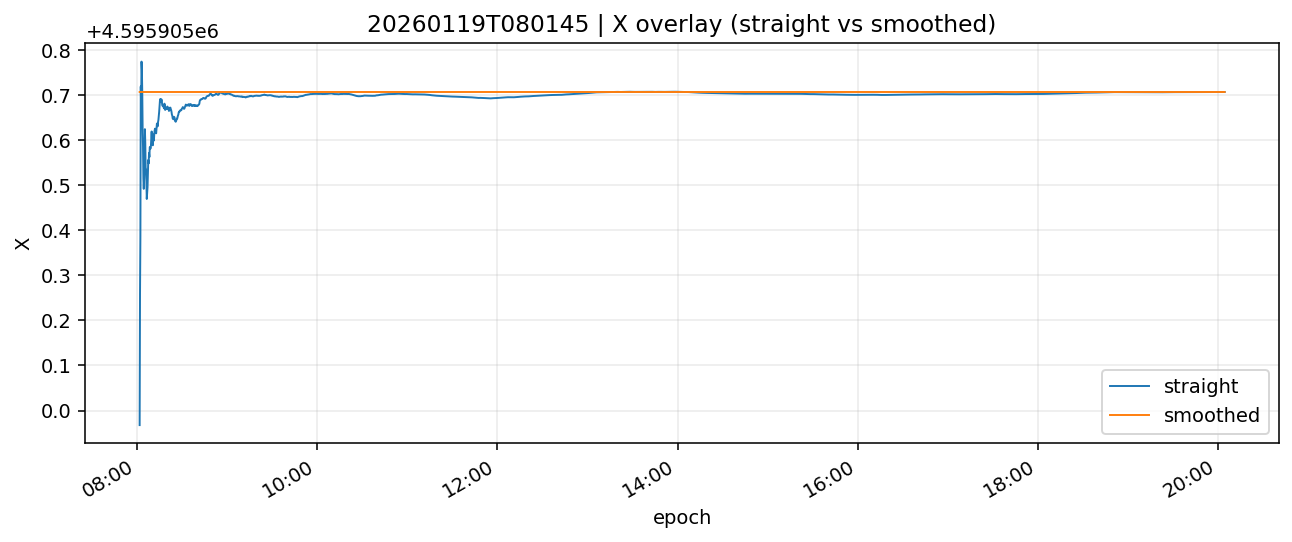
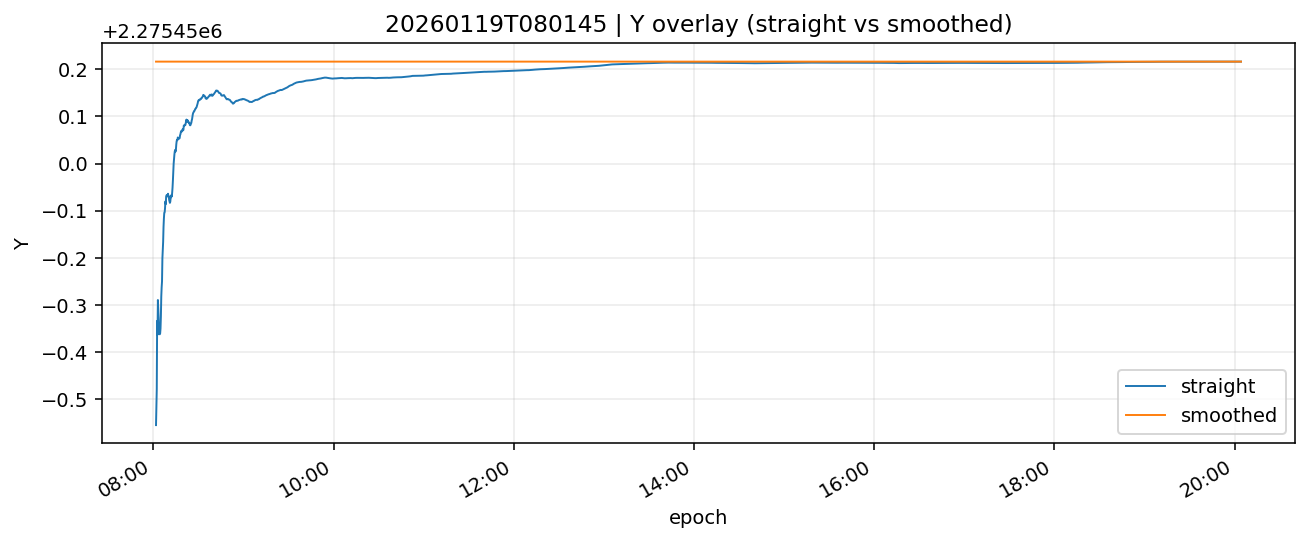
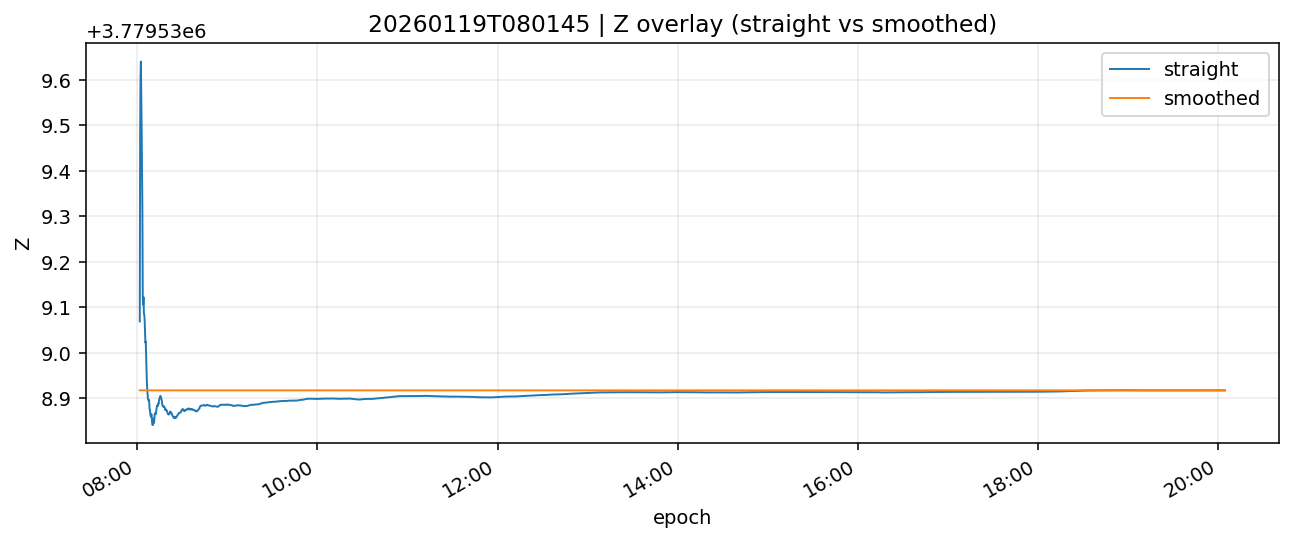
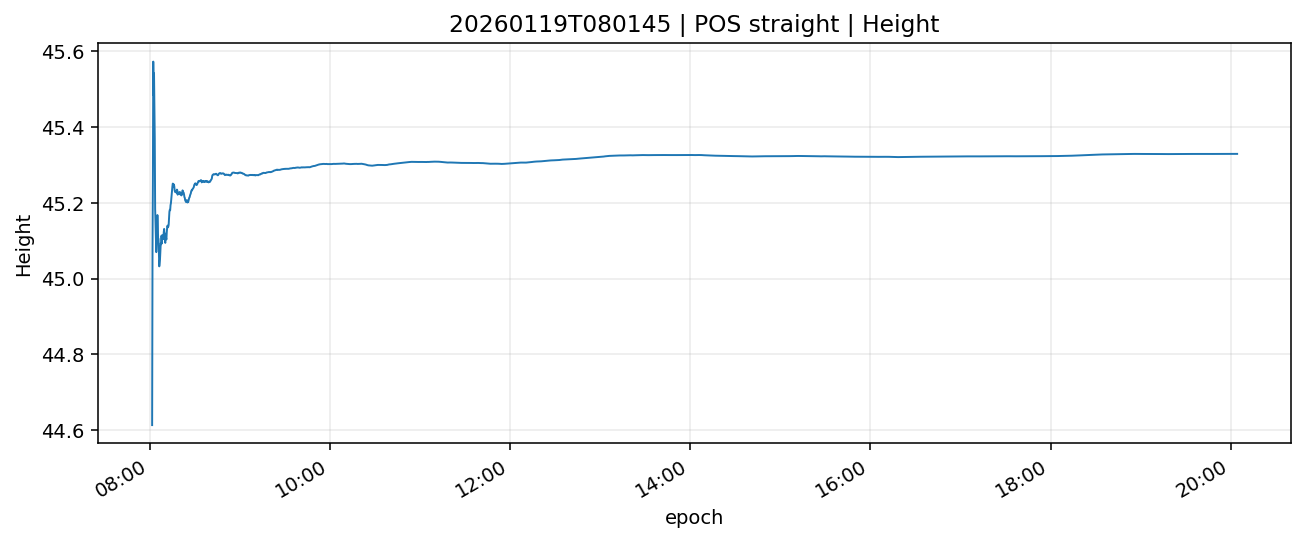
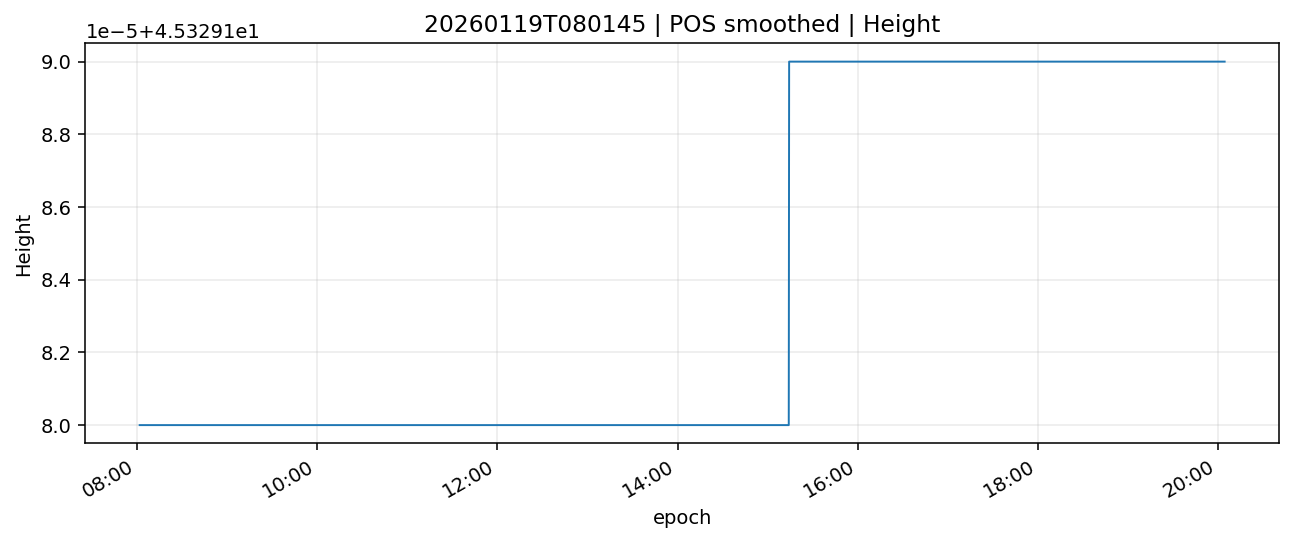
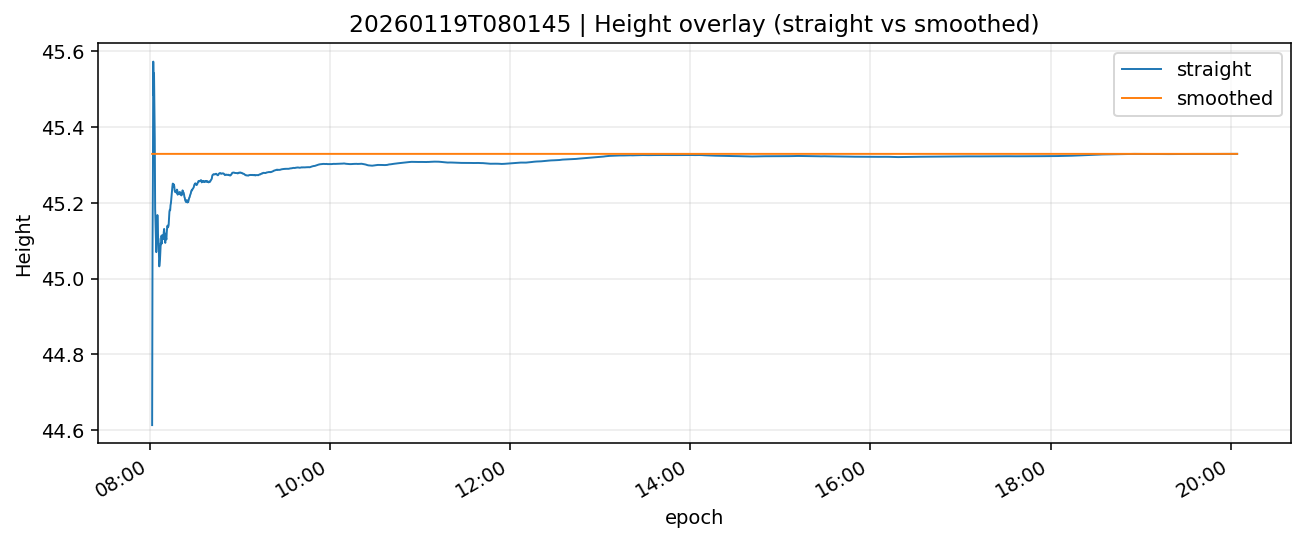

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 12 — Finalize report + display + download (+ save copy under scan_root/Output)
#   - close HTML if not closed
#   - append Warnings summary (time tolerance + unmatched TRACE + strategy mismatches + parse failures)
#   - display inline
#   - offer download
#   - NEW: copy finalized HTML into <scan_root>/Output/
# ============================================================

import re
import shutil
import unicodedata
from pathlib import Path
from html import escape as html_escape
from google.colab import files
from IPython.display import display, HTML

# ----------------------------
# Helpers
# ----------------------------
def _safe_read_text(p: Path) -> str:
    return p.read_text(encoding="utf-8", errors="replace")

def _html_is_closed(html_text: str) -> bool:
    return bool(re.search(r"</html>\s*$", html_text, flags=re.IGNORECASE))

def _append_once(marker: str, fragment: str):
    """
    Ensures we don't append a section twice by checking a marker string.
    """
    txt = _safe_read_text(REPORT_HTML)
    if marker in txt:
        return False
    report_append(fragment)
    return True

def _collect_warnings_from_sessions():
    """
    Collects warning strings produced across cells from in-memory structures.
    Returns dict with categories -> list of strings.
    """
    out = {
        "time_tolerance": [],
        "unmatched_trace": [],
        "strategy_mismatch": [],
        "missing_items": [],
        "parse_failures": [],
        "other": []
    }

    for sid in sorted(SESSIONS.keys()):
        sess = SESSIONS[sid]

        for f in sess.get("flags", []) or []:
            msg = f"Session {sid}: {f}"
            fl = f.lower()
            if "tolerance" in fl and "trace" in fl:
                out["time_tolerance"].append(msg)
            elif "unmatched trace" in fl or "unattached trace" in fl:
                out["unmatched_trace"].append(msg)
            elif "strategy" in fl and "mismatch" in fl:
                out["strategy_mismatch"].append(msg)
            elif "missing" in fl:
                out["missing_items"].append(msg)
            elif "parse" in fl or "failed" in fl:
                out["parse_failures"].append(msg)
            else:
                out["other"].append(msg)

    return out

def _collect_strategy_diffs_summary():
    """
    Summarize STRATEGY_DIFFS into human-readable lines.
    """
    lines = []
    if "STRATEGY_DIFFS" not in globals() or not STRATEGY_DIFFS:
        return lines

    grouped = {}
    for d in STRATEGY_DIFFS:
        sid = d.get("session_id", "")
        variant = d.get("variant", "")
        grouped.setdefault((sid, variant), []).append(d)

    for (sid, variant) in sorted(grouped.keys()):
        diffs = grouped[(sid, variant)]
        keys = [x.get("key", "") for x in diffs if x.get("key")]
        keys = keys[:20]
        line = f"Session {sid} ({variant}): {len(diffs)} Tier-1 mismatch(es). Keys: " + ", ".join(keys)
        lines.append(line)
    return lines

def _collect_report_warnings_by_regex():
    """
    Fallback: scan the HTML for WARNING snippets inserted via html_warn().
    Returns unique warning lines (plain text), without HTML tags.
    """
    txt = _safe_read_text(REPORT_HTML)
    matches = re.findall(r"WARNING:</b>\s*<b[^>]*>(.*?)</b>", txt, flags=re.IGNORECASE | re.DOTALL)
    clean = []
    for m in matches:
        s = re.sub(r"<[^>]+>", "", m)
        s = (s.replace("&lt;", "<").replace("&gt;", ">").replace("&amp;", "&")
               .replace("&quot;", '"').replace("&#x27;", "'"))
        s = " ".join(s.split())
        if s:
            clean.append(s)

    seen = set()
    uniq = []
    for s in clean:
        if s not in seen:
            seen.add(s)
            uniq.append(s)
    return uniq

def _html_list(items):
    if not items:
        return "<p>(none)</p>"
    return "<ul>" + "".join([f"<li>{html_escape(s)}</li>" for s in items]) + "</ul>"

def _nfc(s: str) -> str:
    return unicodedata.normalize("NFC", s)

# ----------------------------
# Warnings summary section
# ----------------------------
marker = "<!-- WARNINGS_SUMMARY -->"

warnings_struct = _collect_warnings_from_sessions()
strategy_lines = _collect_strategy_diffs_summary()
regex_warns = _collect_report_warnings_by_regex()

sections = []
sections.append(marker)
sections.append("<h2>Warnings summary</h2>")
sections.append("<p>Summary of warnings collected from session flags and report warnings.</p>")

sections.append("<h3>Strategy mismatches (Tier-1)</h3>")
sections.append(_html_list(strategy_lines if strategy_lines else warnings_struct["strategy_mismatch"]))

sections.append("<h3>TRACE ↔ POS time tolerance matches</h3>")
sections.append(_html_list(warnings_struct["time_tolerance"]))

sections.append("<h3>Unmatched / unattached TRACE files</h3>")
sections.append(_html_list(warnings_struct["unmatched_trace"]))

sections.append("<h3>Missing items (POS/TRACE)</h3>")
sections.append(_html_list(warnings_struct["missing_items"]))

sections.append("<h3>Parse failures</h3>")
sections.append(_html_list(warnings_struct["parse_failures"]))

if regex_warns:
    sections.append("<h3>All WARNING messages found in report</h3>")
    sections.append(_html_list(regex_warns))

_appended = _append_once(marker, "\n".join(sections))

# ----------------------------
# Close HTML if needed
# ----------------------------
html_now = _safe_read_text(REPORT_HTML)
if not _html_is_closed(html_now):
    report_close()
    html_now = _safe_read_text(REPORT_HTML)

# ----------------------------
# NEW: Save a copy under scan_root/Output
# ----------------------------
saved_copy_path = None
try:
    if "scan_root" in globals() and scan_root is not None:
        sr = Path(_nfc(str(scan_root))).expanduser().resolve()
        if sr.exists() and sr.is_dir():
            out_dir = sr / "Output"
            out_dir.mkdir(parents=True, exist_ok=True)
            saved_copy_path = (out_dir / Path(REPORT_HTML).name).resolve()
            shutil.copy2(str(REPORT_HTML), str(saved_copy_path))
except Exception as e:
    print("WARNING: Could not copy report into scan_root/Output:", e)

# ----------------------------
# Display + download
# ----------------------------
print("Report path (working dir):", REPORT_HTML)
if saved_copy_path is not None:
    print("Report copy saved under scan_root/Output:", saved_copy_path)

display(HTML(html_now))

try:
    files.download(str(REPORT_HTML))
except Exception as e:
    print("Download not available in this environment:", e)


**Giagnostic routines**

In [ ]:
from pathlib import Path

p = Path("/content/drive/MyDrive/ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/GINAN post processing/_337_default_config_HEAD_202601900.POS")
lines = p.read_text(encoding="utf-8", errors="replace").splitlines()

print("Total lines:", len(lines))
print("---- HEAD (first 40) ----")
for i, L in enumerate(lines[:40]):
    print(f"{i+1:03d}: {repr(L[:160])}")

print("---- TAIL (last 20) ----")
for i, L in enumerate(lines[-20:], start=len(lines)-20+1):
    print(f"{i:03d}: {repr(L[:160])}")


In [ ]:
print("choice     =", repr(choice) if "choice" in globals() else "<not defined>")
print("drive_mode =", repr(drive_mode) if "drive_mode" in globals() else "<not defined>")
print("scan_root  =", repr(str(scan_root)) if "scan_root" in globals() else "<not defined>")
print("scan_root exists =", (Path(scan_root).exists() if "scan_root" in globals() else "<n/a>"))


**OLD VERSION CODE**